# Beyond BLAST Notebook

In [1]:
ENV["JULIA_PKG_PRECOMPILE_AUTO"] = 0;
using Pkg
Pkg.activate("blast_code"; io=devnull)
Pkg.resolve(; io=devnull)
Pkg.instantiate(; io=devnull)

using Revise 
using Base.Threads, HDF5, NPZ, DataInterpolations, Interpolations, FastChebInterp
using BenchmarkTools, FFTW, FastTransforms, Dates, TOML, Plots, Plots.Measures
using QuadGK, LaTeXStrings, Tullio, StaticArrays, LoopVectorization, LinearAlgebra
using Unitful, SpecialFunctions, DifferentialEquations, Cosmology, NumericalIntegration
using CSV, DataFrames, JSON, OrderedCollections
;

[ Info: Precompiling HDF5 [f67ccb44-e63f-5c2f-98bd-6dc0ccc4ba2f]
[ Info: Precompiling DataInterpolations [82cc6244-b520-54b8-b5a6-8a565e85f1d0]
Precompiling packages...
   1977.3 ms  ✓ DataInterpolations → DataInterpolationsChainRulesCoreExt
  1 dependency successfully precompiled in 3 seconds. 37 already precompiled.
[ Info: Precompiling DataInterpolationsChainRulesCoreExt [187dfacc-d000-5da0-94aa-5ec8eb045cfd]
┌ Warning: Module DataInterpolations with build ID fafbfcfd-3916-580a-4458-989b9327c778 is missing from the cache.
│ This may mean DataInterpolations [82cc6244-b520-54b8-b5a6-8a565e85f1d0] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:2022
[ Info: Skipping precompilation since __precompile__(false). Importing DataInterpolationsChainRulesCoreExt [187dfacc-d000-5da0-94aa-5ec8eb045cfd].
Precompiling packages...
    577.9 ms  ✓ FastChebInterp
  1 dependency successfully precompiled in 1 seconds. 18 already precompiled.
[ Info: Precompili

#### Including the .jl modules

In [2]:
include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")
include("blast_code/src/galaxy_galaxy.jl")
include("blast_code/src/shear_shear.jl")
include("blast_code/src/config.jl")
include("blast_code/src/paths.jl")
include("blast_code/src/plot_config.jl")
using .galaxy_galaxy
using .shear_shear
using .Blast
using .blast_tutorials

#### Defining an output folder for each run

#### Setting run parameters, plot parameters, and grids in k

In [3]:
#sets the paths for the output directories 
paths = setup_output_directories()
#sets up the cosmology grid and returns the parameters
grid_data = setup_cosmology_grid() 
#sets up the plotting theme and returns the parameters
plot_theme = setup_plot_theme() 
#returns the k grids for the calculations
grids = Blast.generate_k_grids(grid_data.kmin, grid_data.kmax, grid_data.Nk, grid_data.Nkp, grid_data.Nkpp; sorting=false) 
# #saves the run parameters in a txt file
params_run = save_run_config(
    paths.output_dir, grid_data.N, 
    grid_data.xmin, grid_data.xmax, grid_data.zmin, grid_data.zmax, grid_data.kmin, grid_data.kmax, 
    grid_data.n_cheb, grid_data.ℓ, grid_data.Nk, grid_data.Nkp, grid_data.Nkpp,
    grid_data.x, grid_data.z, 
    grids.k_grid, grids.kp_grid, grids.kpp_grid, grids.sorting)
;

Folders in place: out/runs/run_2026_07_15_103319, out/runs/run_2026_07_15_103319/plots and out/runs/run_2026_07_15_103319/quantities
Data brought to safety in folder: out/runs/run_2026_07_15_103319


In [6]:
println(grids.k_grid[147])

0.01574015850603505


In [7]:
#run parameters
reuse = true #if set to true, the code will load the W_tilde. 
mode = "fast" 
# fast -> # Nk = Nkp = Nkpp = 150
# big ->  # Nk = Nkp = Nkpp = 350

"fast"

In [8]:
println(grids.k_grid[1])
println(grids.k_grid[end])
println(grid_data.kmin)
println(grid_data.kmax)

15.384615384615385
0.00035714285714227856
0.00035714285714285714
15.384615384615385


In [9]:
append_to_log(paths.output_dir, "=== Run started ===")

### Galaxy clustering factor

$bias = b(z,z^2,z^3)$
comes from [this paper](https://arxiv.org/pdf/1807.10331)

Defining the kernel/window function for a galaxy probe: the window function is \
\
$W(z) = \frac{H(z) n(z) \chi(z)^2 b(z) D(z)}{c} $ \
\
where \
\
$n(z) = A (\frac{z}{z_0})^{\alpha} exp[{-(\frac{z}{z_0})^{\beta}}] $, \
\
with $A = \frac{1.5}{z_0}$, $\alpha = 2$ and $\beta = 1.5$ \
\
$b(z) = b_0 \sqrt{1+z} $ and $b_0 = 1$ \
\
$D(z) = \frac{D(z)^{unnorm}}{D(0)^{unnorm}}$, \
\
with $D(z)^{unnorm} = E(z) \int_z^{\infty} dz' \frac{1+z'}{E(z')^3} $ 

As for the ````gal_prefactor_W_cheb````, it is obtained interpolating each factor, ````bias````, ````growth````, ````nz_norm````, ````chi```` on the ````z````, and then obtaining the total interpolated product ````gal_prefact_W_cheb````.

As for the ````cheb_coeff_gal````, I compute this similarly to Blast: I define a ````plan```` object that takes the ````gal_prefact_W_cheb```` as input, and then returns the ````cheb_coeff```` as the output of the functions ````fast_chebcoefs````

In [10]:
gal_prefact_W, bias, growth, Hubble_param, nz_norm = galaxy_galaxy.galaxy_prefactor(grid_data.x, grid_data.z, grid_data.cosmo; 
                                                     output_dir=paths.output_dir, plot_style = plot_theme.shared_style);
gal_prefact_W_cheb = galaxy_galaxy.galaxy_prefactor_cheb(grid_data.xmin, grid_data.xmax, grid_data.n_cheb, grid_data.z, grid_data.x, 
                                                         bias, growth, Hubble_param, nz_norm; 
                                                         output_dir=paths.output_dir);

Plots will be saved in: out/runs/run_2026_07_15_103319/plots/kernels/
Quantities will be saved in: out/runs/run_2026_07_15_103319/quantities/
Comoving distance vs redshift plot saved.
Bias plot saved.
Growth factor plot saved.
Hubble factor plot saved.
n(z) vs redshift plot saved.
Normalized n(z) vs redshift plot saved.
n(z) vs redshift plot saved.
W(z) plot saved.
Normalized kernel plot saved.
Unnormalized kernel plot saved.
W(z) prefactor saved: out/runs/run_2026_07_15_103319/quantities/prefac_galaxy.npy
W(z) prefactor on Chebyshev grid saved: out/runs/run_2026_07_15_103319/quantities/prefac_on_cheb_galaxy.npy


Is it true that

$W(\chi) \approx \sum_{n=0}^{N_{cheb}-1} c_n T_n(\chi)$ ?

It seems that the kernel computed on the grid of comoving distances $\chi$, when computed on the Chebyshev nodes, has this behaviour

In [11]:
npzwrite(joinpath(paths.output_dir, "galaxy_prefactor_W.npy"), gal_prefact_W)
append_to_log(paths.output_dir, "galaxy_prefactor_W.npy saved.")
append_to_log(paths.output_dir, "the size of gal_prefact_W is $(size(gal_prefact_W)).")

In [12]:
println("Kernel on normal nodes at the end of the array: ")
println(gal_prefact_W[end])
println("Kernel on Chebyshev nodes at the start of the array: ")
println(gal_prefact_W_cheb[1])
println("Kernel on normal nodes at the start of the array: ")
println(gal_prefact_W[1])
println("Kernel on Chebyshev nodes at the end of the array: ")
println(gal_prefact_W_cheb[end])

Kernel on normal nodes at the end of the array: 
0.11956145604640839
Kernel on Chebyshev nodes at the start of the array: 
0.11956145604640839
Kernel on normal nodes at the start of the array: 
6.644684574514392e-9
Kernel on Chebyshev nodes at the end of the array: 
6.644684574514392e-9


So one could verify whether the two object are the same just by indexing in a reverse way the Chebyshev object

In [13]:
# questo diventa superfluo.
gal_prefact_cheb_ord = reverse!(gal_prefact_W_cheb); #this is the same as doing gal_prefact_cheb_ord = gal_prefact_W_cheb[end:-1:1];

In [14]:
cheb_coeff_gal = galaxy_galaxy.compute_prefactor_chebcoeffs(gal_prefact_cheb_ord; output_dir=paths.output_dir);

W(z) Chebyshev coefficients saved: out/runs/run_2026_07_15_103319/quantities/W_cheb_coeff_galaxy.npy


In [15]:
println("Kernel on normal nodes at the end of the array: ")
println(gal_prefact_W[end])
println("Kernel on Chebyshev nodes at the start of the array, now reversed: ")
println(gal_prefact_cheb_ord[end])

Kernel on normal nodes at the end of the array: 
0.11956145604640839
Kernel on Chebyshev nodes at the start of the array, now reversed: 
0.11956145604640839


Here I plot che object on normal nodes vs the N comoving distances $\chi$, and the object on Chebyshev nodes vs the $n_{cheb}$ comoving distances

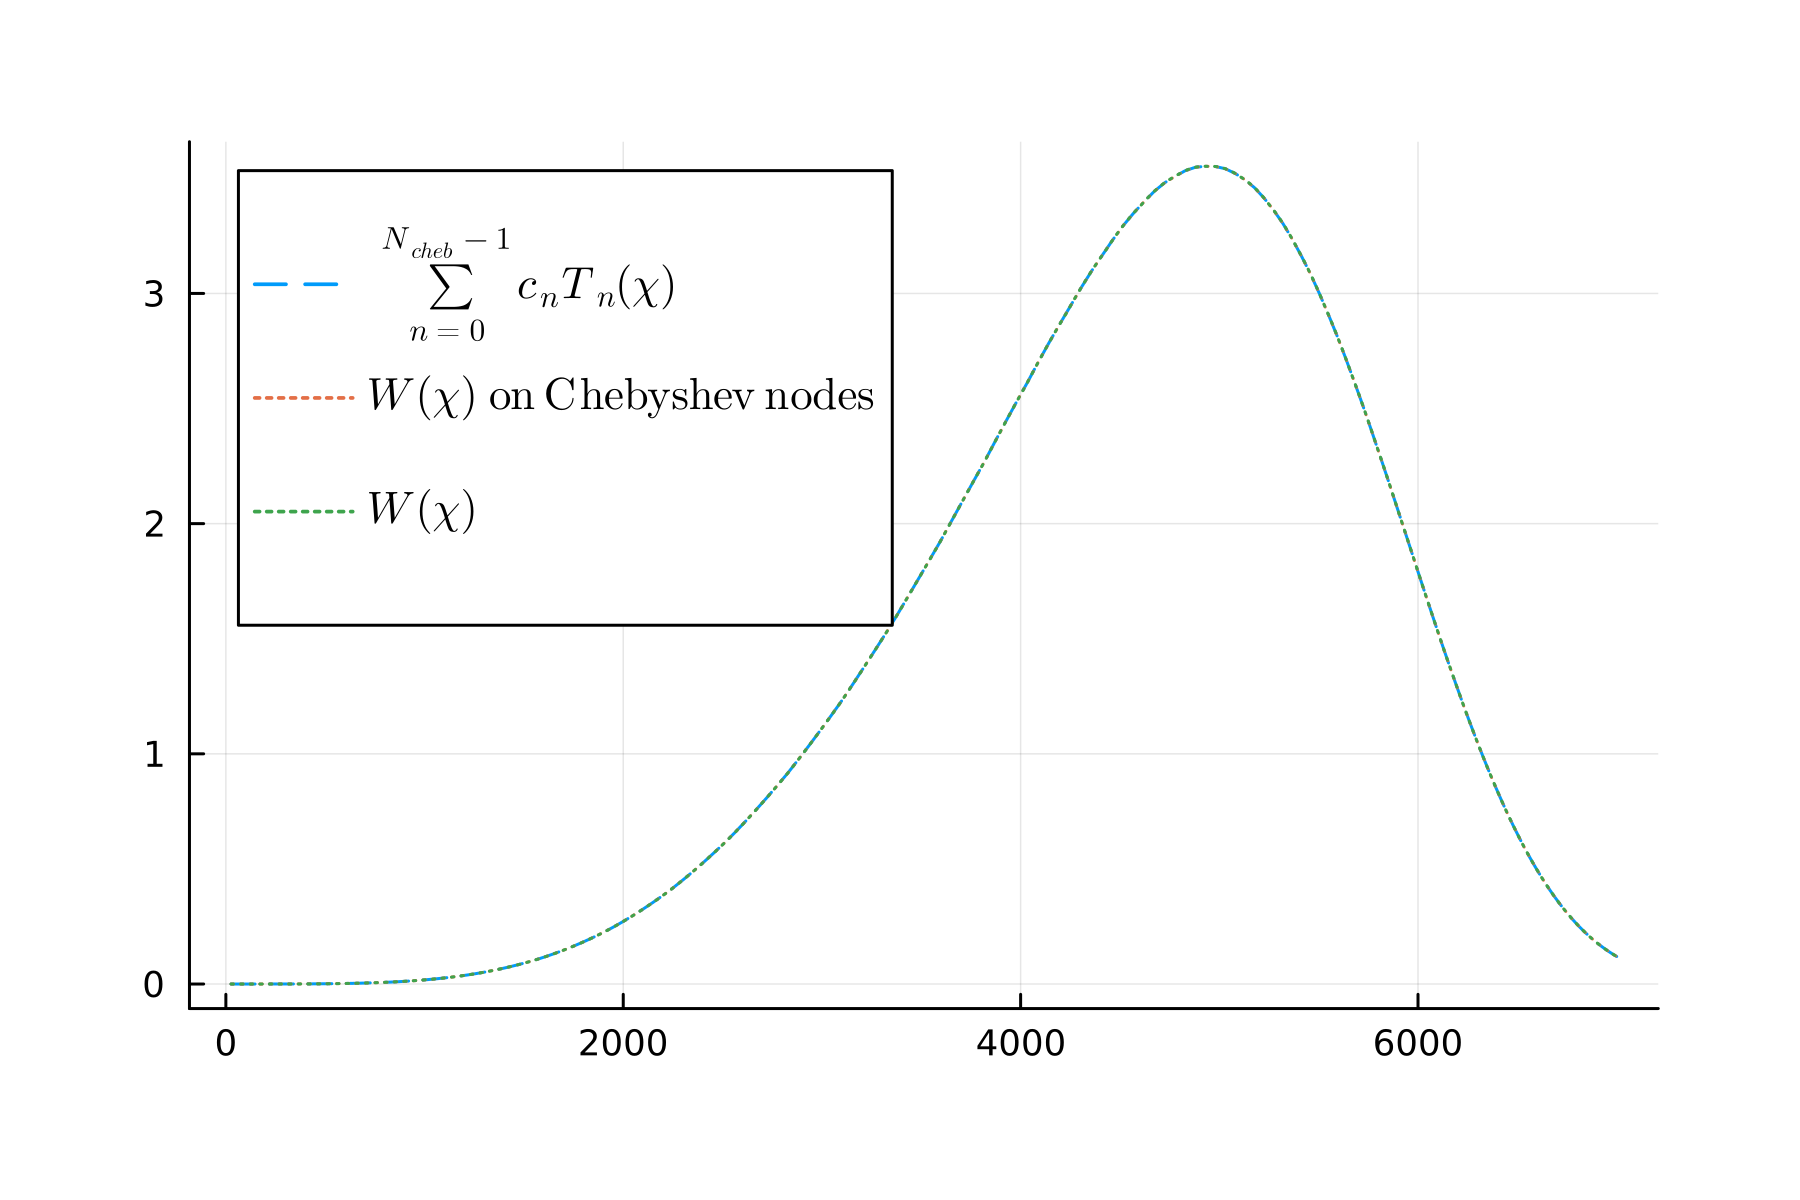

In [16]:
x_cheb_plot = Blast.get_clencurt_grid(grid_data.xmax, grid_data.xmin, grid_data.n_cheb)
z_interp = DataInterpolations.AkimaInterpolation(grid_data.z, grid_data.x, extrapolation=ExtrapolationType.Linear)
z_cheb_plot = z_interp.(x_cheb_plot)
plot(x_cheb_plot, gal_prefact_cheb_ord, label = L"\sum_{n=0}^{N_{cheb}-1} c_n T_n(\chi)", ls=:dash, markersize=0.1, markercolor =:blue)
plot!(x_cheb_plot, gal_prefact_W_cheb, label = L"W(\chi) \; \mathrm{on} \; \mathrm{Chebyshev} \; \mathrm{nodes}", lw=1, ls=:dot; plot_theme.shared_style...)
plot!(grid_data.x, gal_prefact_W, label = L"W(\chi)", lw=1, ls=:dot; plot_theme.shared_style...)

Now I want to compute the relative error between the $W(z)$ and $W(z_cheb)$. To do so, they have to share the same grid. So I bring the normal W(z), previously computed on N nodes, on the Chebyshev grid. 
Note that the object is computed using both $\chi$ and $z$ obtained through get_clencurt_grid, so there's no need to reverse it at the end. 

In [17]:
galW_computed_on_cheb, _, _, _, _ = galaxy_galaxy.galaxy_prefactor(x_cheb_plot, z_cheb_plot, grid_data.cosmo; output_dir=paths.output_dir);

Plots will be saved in: out/runs/run_2026_07_15_103319/plots/kernels/
Quantities will be saved in: out/runs/run_2026_07_15_103319/quantities/
Comoving distance vs redshift plot saved.
Bias plot saved.
Growth factor plot saved.
Hubble factor plot saved.
n(z) vs redshift plot saved.
Normalized n(z) vs redshift plot saved.
n(z) vs redshift plot saved.
W(z) plot saved.
Normalized kernel plot saved.
Unnormalized kernel plot saved.
W(z) prefactor saved: out/runs/run_2026_07_15_103319/quantities/prefac_galaxy.npy


Now that I have the two object on the same grid, I once again plot the two

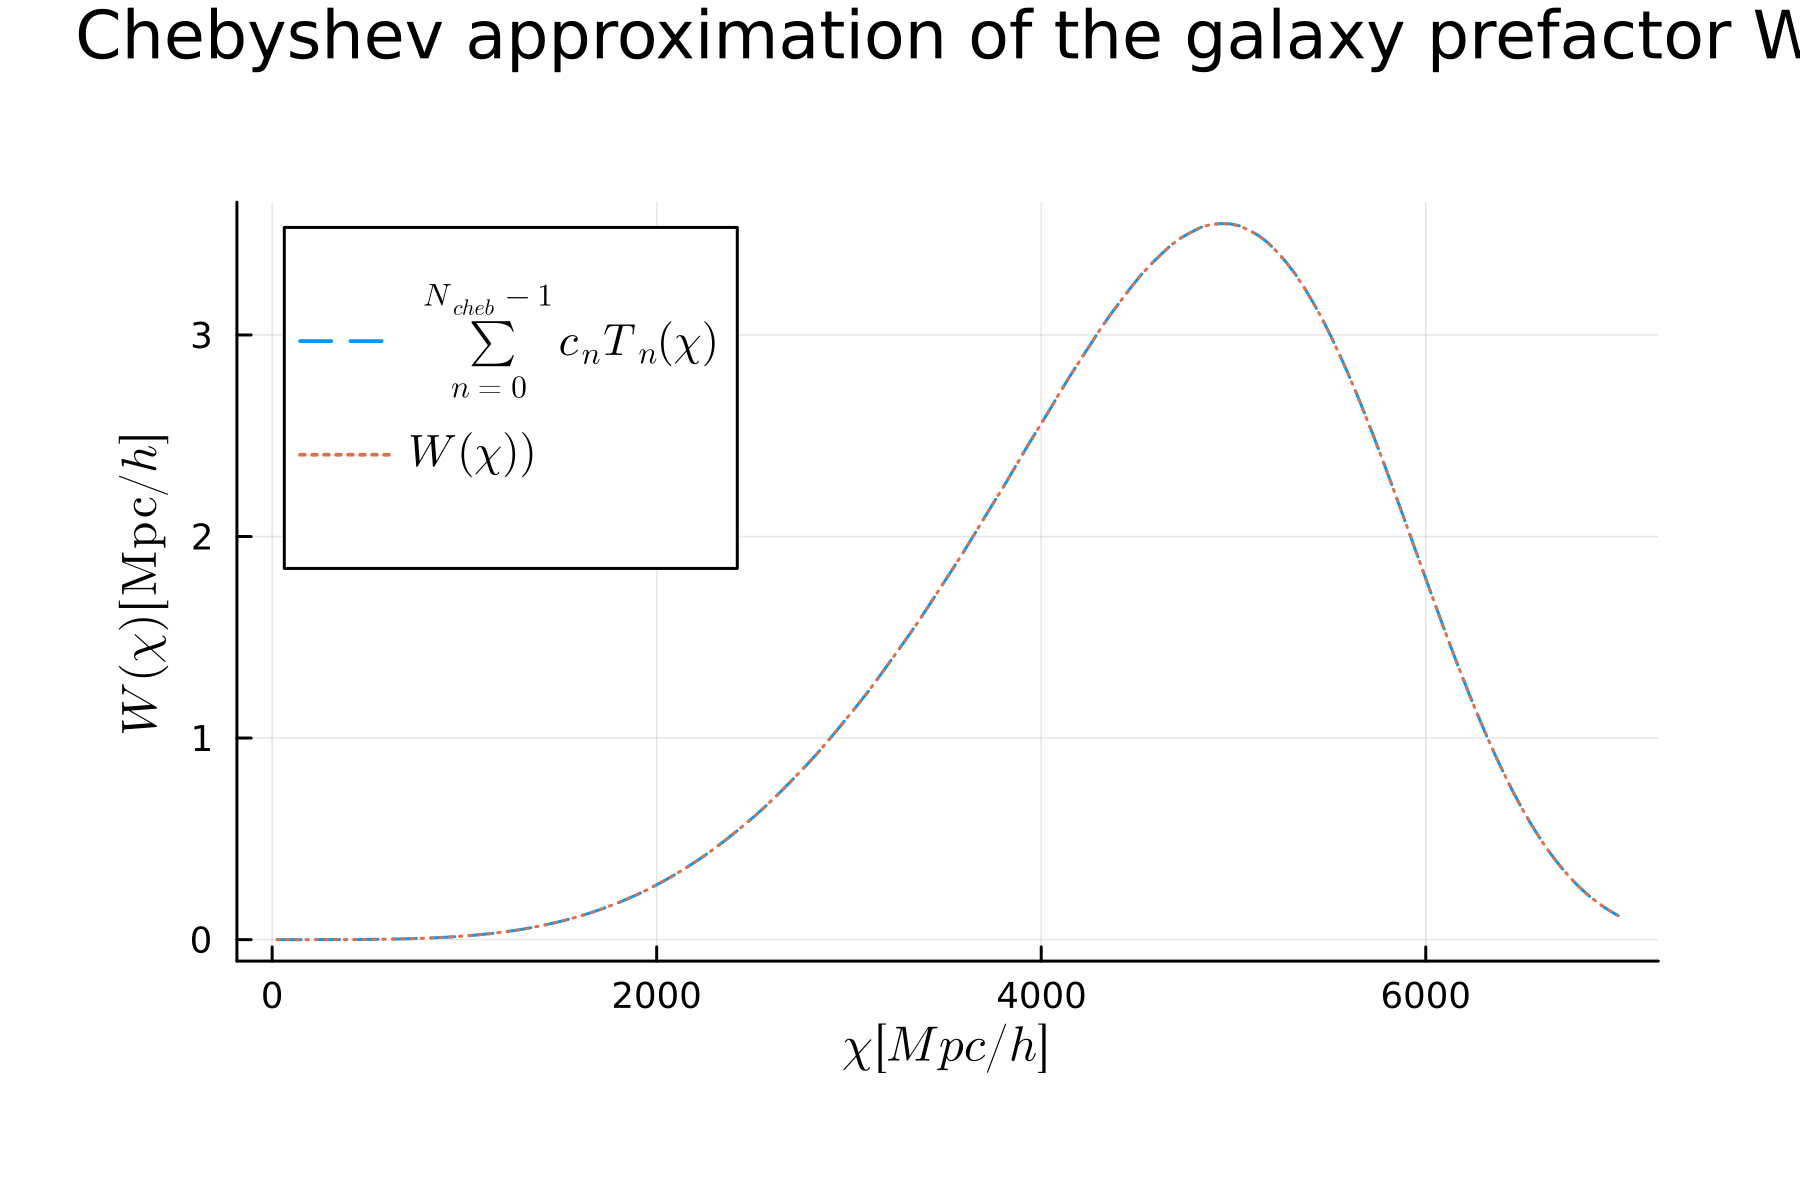

In [18]:
plot(x_cheb_plot, gal_prefact_W_cheb, label = L"\sum_{n=0}^{N_{cheb}-1} c_n T_n(\chi)", ls=:dash, markersize=0.1, markercolor =:blue)
plot!(x_cheb_plot, galW_computed_on_cheb, label = L"W(\chi))", lw=1, ls=:dot)
plot!(dpi = 300, legendposition = :topleft, xlabel = L"\chi [Mpc/h]", ylabel = L"W(\chi) [\mathrm{Mpc}/h]",
        title = "Chebyshev approximation of the galaxy prefactor W"; plot_theme.shared_style...)

In [19]:
rel_err = (gal_prefact_W_cheb ./ galW_computed_on_cheb) .- 1
rel_err_abs = abs.(rel_err)
rel_err_pct = 100 .* rel_err
rel_err_pct_abs = 100 .* rel_err_abs
;

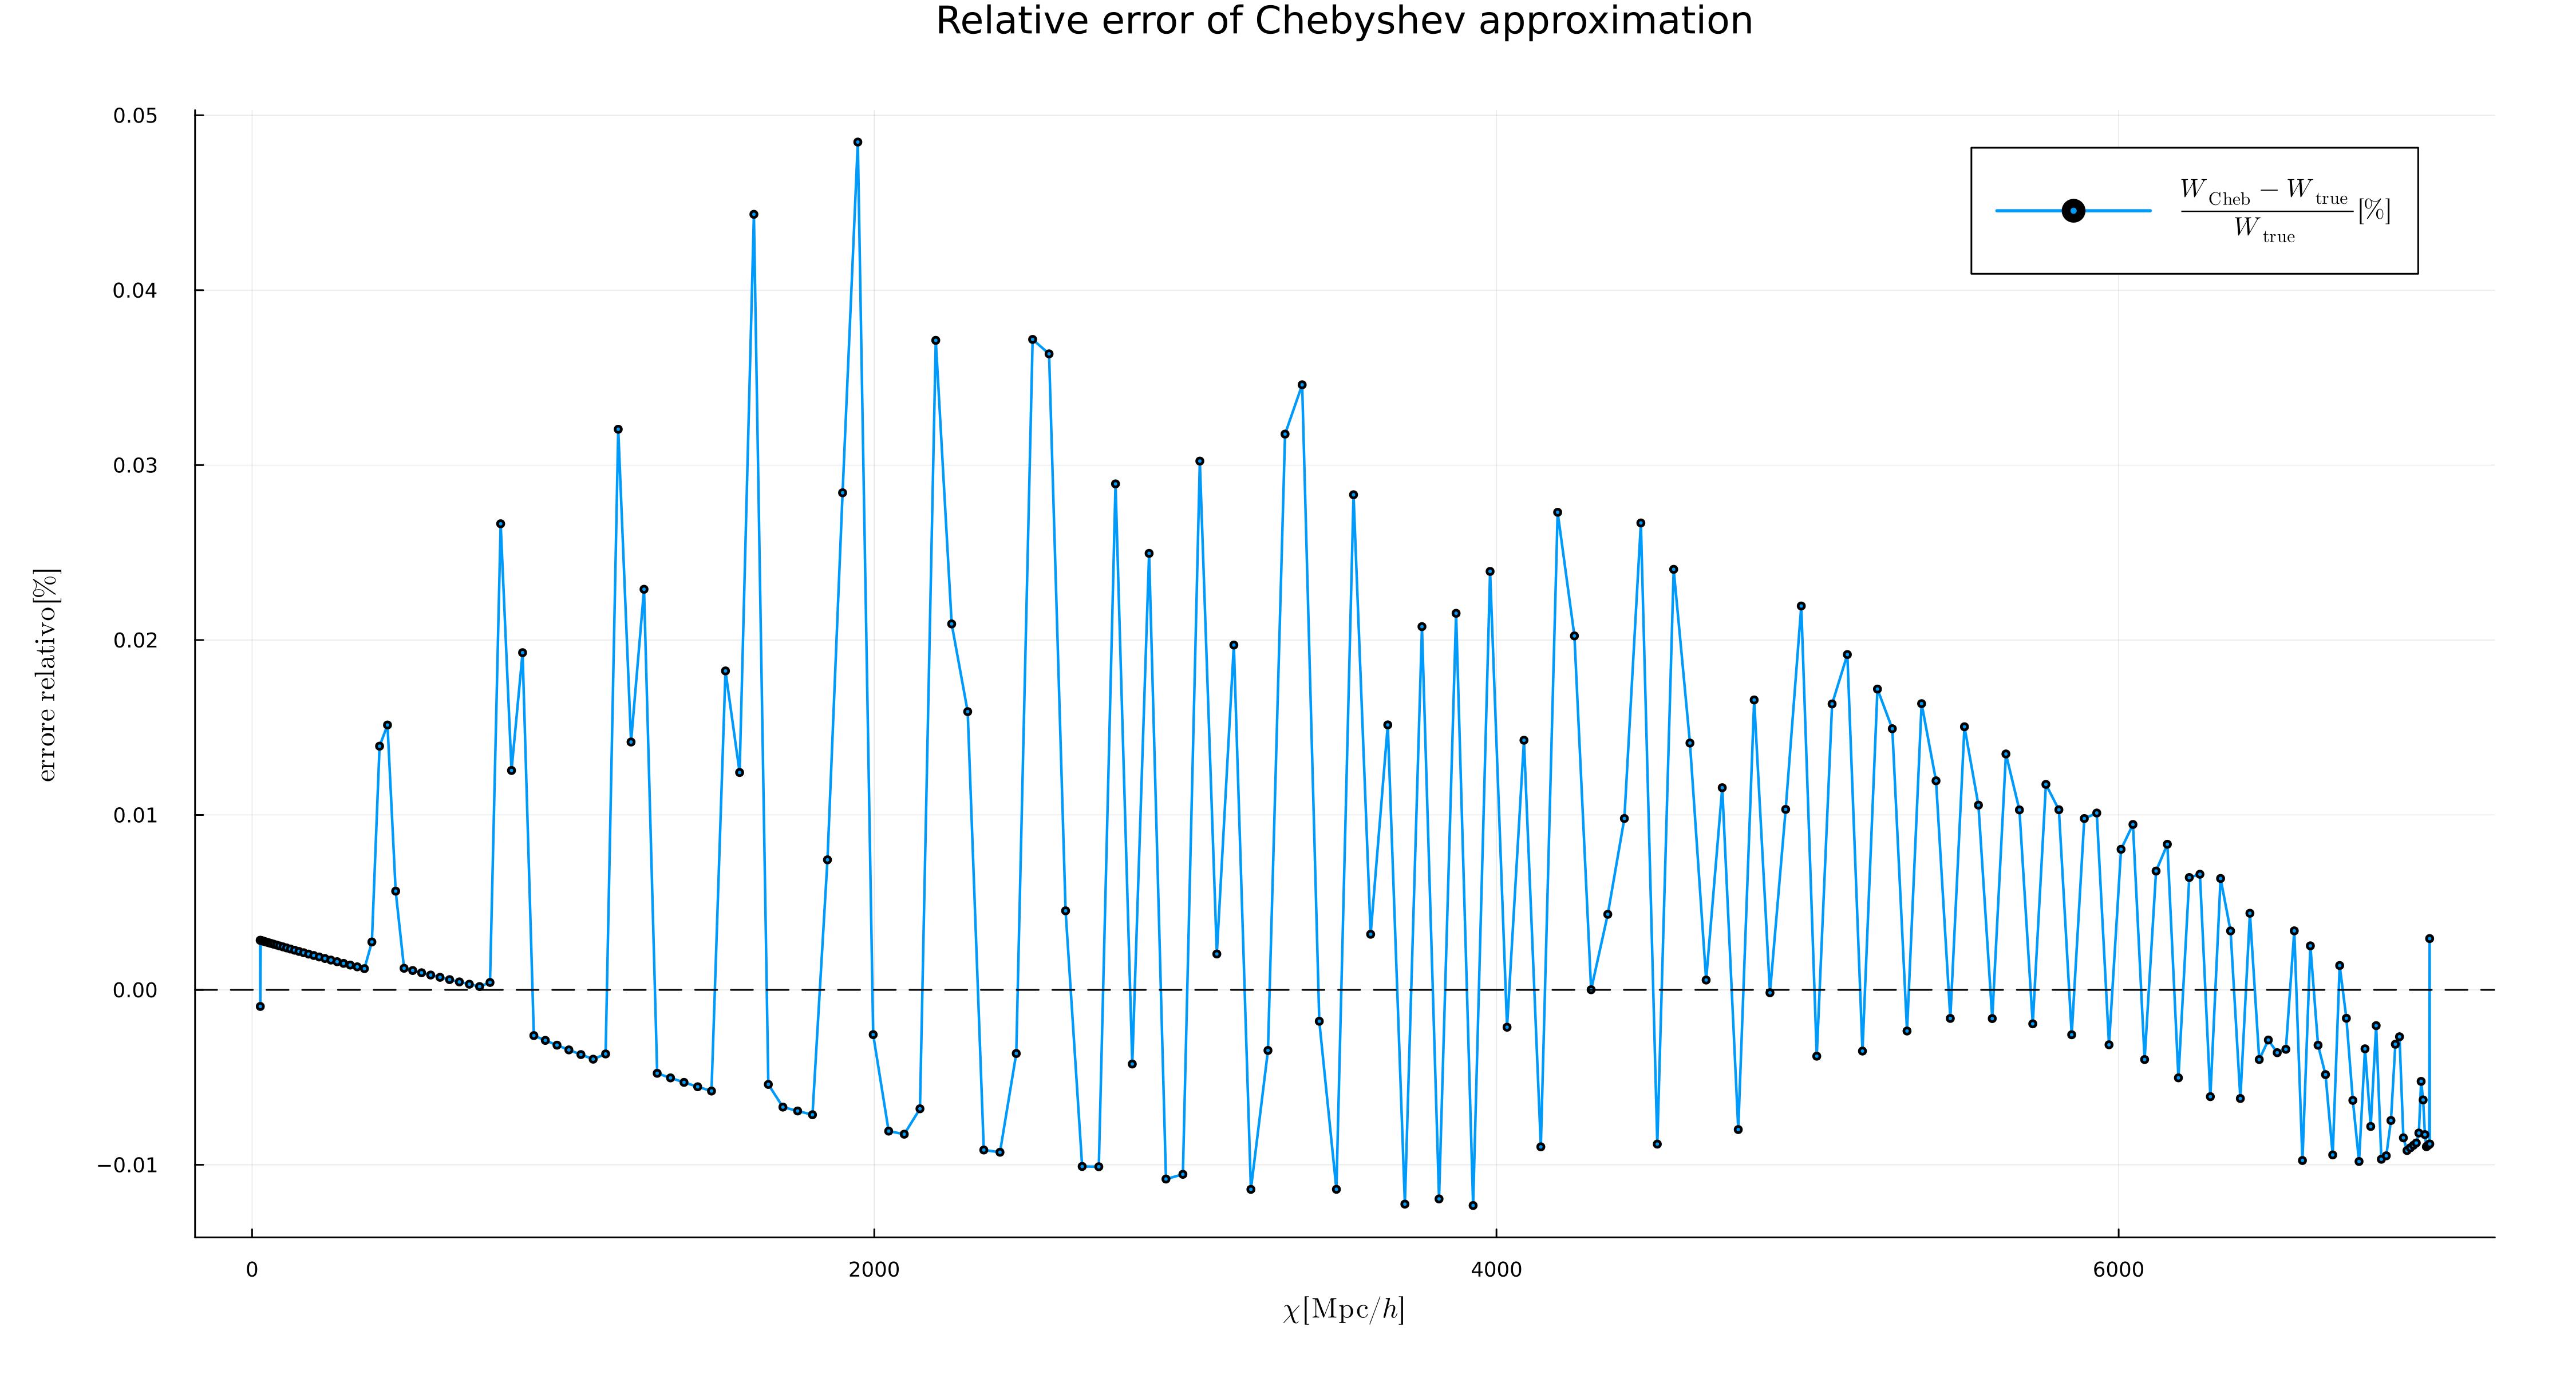

In [20]:
plot(
    x_cheb_plot, rel_err_pct,
    label = L"\frac{W_{\mathrm{Cheb}} - W_{\mathrm{true}}}{W_{\mathrm{true}}}\,[\%]",
    lw = 1.5,
    marker = :circle,
    markersize = 2,
    legendposition = :topright,
    xlabel = L"\chi\,[\mathrm{Mpc}/h]",
    ylabel = L"\mathrm{errore\ relativo}\,[\%]",
    title = "Relative error of Chebyshev approximation", size=plot_theme.size_Cl; plot_theme.shared_style...
    )

hline!([0.0], ls = :dash, lw = 1, color = :black, label = false)


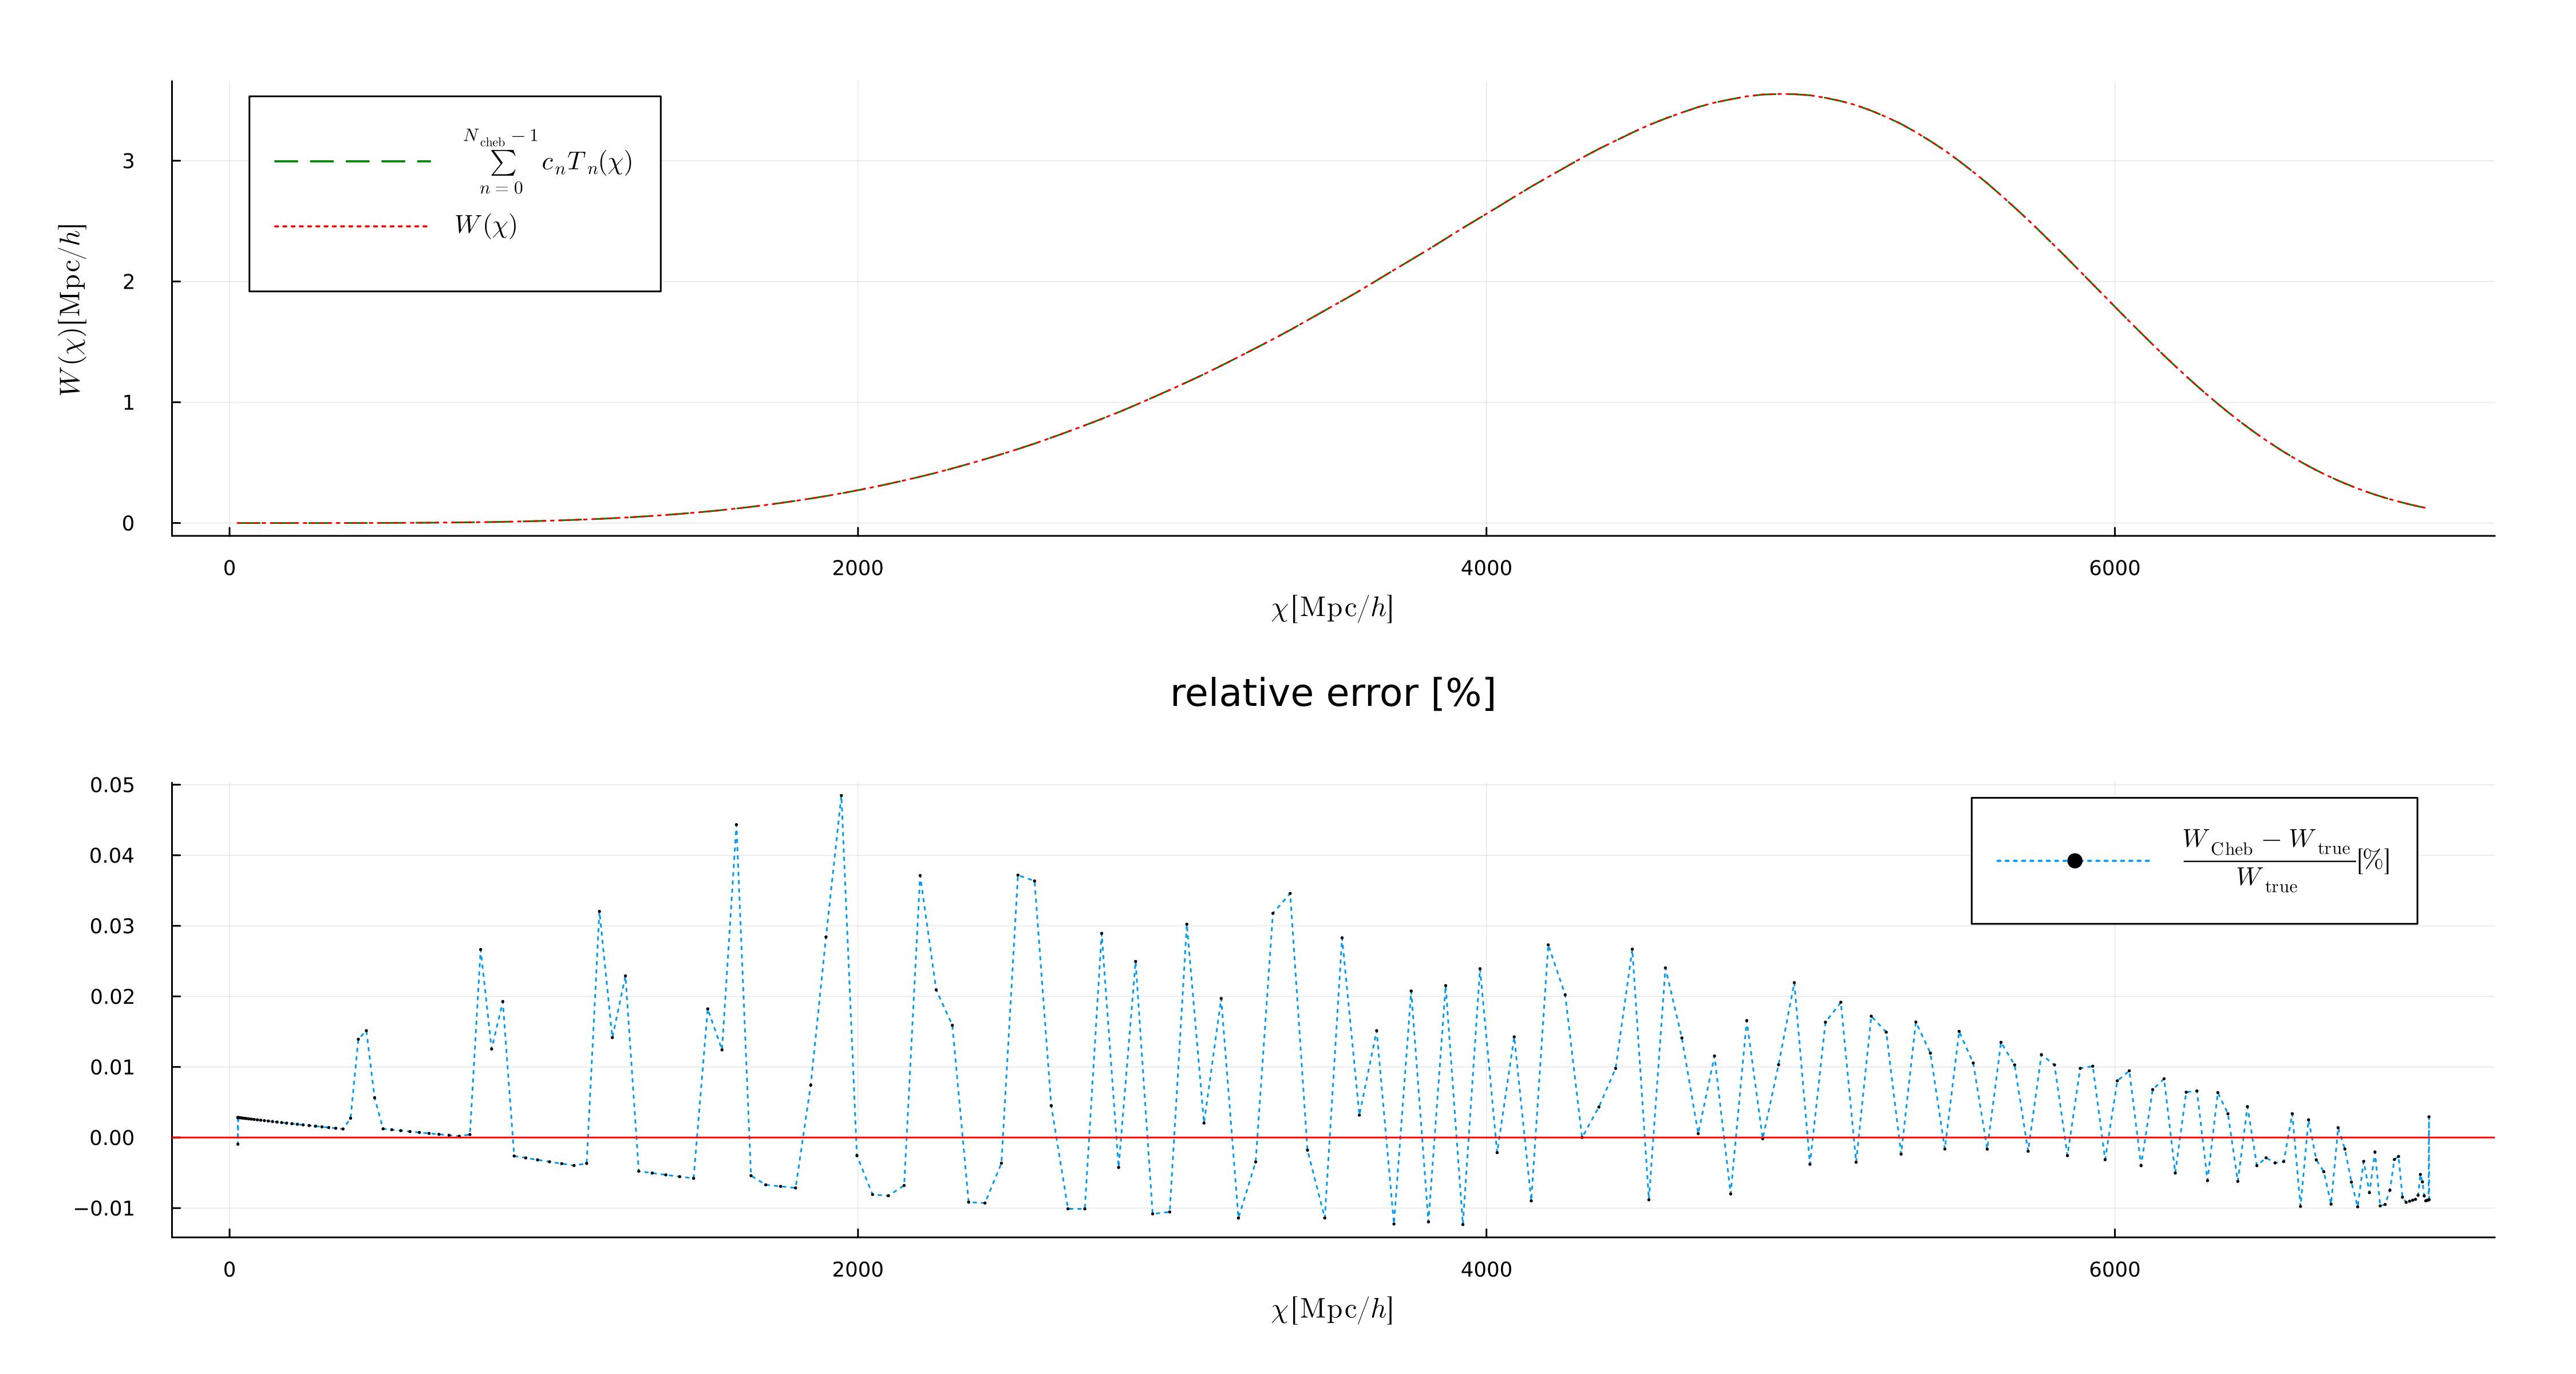

In [21]:
p1 = plot(
    x_cheb_plot, galW_computed_on_cheb,
    label = L"\sum_{n=0}^{N_{\mathrm{cheb}}-1} c_n T_n(\chi)",
    ls = :dash, color = :green)
plot!(p1, x_cheb_plot, gal_prefact_W_cheb, label = L"W(\chi)", lw = 1, ls = :dot, color = :red)
plot!(p1, dpi = 300, legendposition = :topleft, xlabel = L"\chi [Mpc/h]", ylabel = L"W(\chi) [\mathrm{Mpc}/h]", 
        size = plot_theme.size_Cl; plot_theme.shared_style...
        )
    
p2 = plot(
    x_cheb_plot, rel_err_pct,
    label = L"\frac{W_{\mathrm{Cheb}} - W_{\mathrm{true}}}{W_{\mathrm{true}}} [\%]",
    lw = 1.0, marker = :circle, markercolor = :black, markersize = 1, linestyle = :dot, 
    title = "relative error [%]", titlefontsize = 10
)
hline!(p2, [0.0], ls = :solid, lw = 1, color = :red, label = false)

plot(p1, p2, layout = @layout([a; b]), dpi = 300,
     xlabel = L"\chi\,[\mathrm{Mpc}/h]",
    size = plot_theme.size_Cl; plot_theme.shared_style...)

### The dimension of the Chebyshev coefficients is [n_cheb]

In [22]:
println("size of cheb_coeff_gal: ", size(cheb_coeff_gal))
npzwrite(joinpath(paths.quantity_subdir, "chebcoefs/cheb_coeff_gal.npy"), cheb_coeff_gal)

size of cheb_coeff_gal: (200,)


In [23]:
n_idx = 0:(grid_data.n_cheb - 1)
plot(n_idx, abs.(cheb_coeff_gal),
     yscale = :log10,
     xlabel = L"{grid_data.n_cheb}",
     ylabel = L"|c_{grid_data.n_cheb}|",
     label = L"|c_{grid_data.n_cheb}| \ \mathrm{di} \ W(\chi)",
     title = "Chebyshev coefficients decay",
     marker = :circle, markersize = 3; plot_theme.shared_style...
     )
savefig(joinpath(paths.plot_subdir, "kernels", "chebcoeff_decay_galaxy.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_15_103319/plots/kernels/chebcoeff_decay_galaxy.png"

In [24]:
function cheb_eval_partial(coeffs, x, xmin, xmax, ntrunc)
    t = @. (2*x - (xmax + xmin)) / (xmax - xmin)
    T0 = ones(length(x))
    if ntrunc == 0
        return coeffs[1] .* T0
    end
    T1 = t
    S = coeffs[1] .* T0 .+ coeffs[2] .* T1
    for n in 2:ntrunc
        T2 = @. 2*t*T1 - T0
        S .+= coeffs[n+1] .* T2
        T0, T1 = T1, T2
    end
    return S
end

chi_cheb_nodes = Blast.get_clencurt_grid(grid_data.xmin, grid_data.xmax, grid_data.n_cheb)
x_ref = chi_cheb_nodes
Wref = gal_prefact_W_cheb

truncs = 1:1:length(cheb_coeff_gal)-1
#truncs = [5, 10, 20, 40, 80, 120, 160, length(cheb_coeff_gal)-1]
errs = Float64[]
Wn = zeros(length(x_ref))
for ntrunc in truncs
    Wn = cheb_eval_partial(cheb_coeff_gal, x_ref, grid_data.xmin, grid_data.xmax, ntrunc)
    err = maximum(abs.(Wn .- Wref)) / maximum(abs.(Wref))
    push!(errs, err)
end

truncs_plot = truncs[1:end]
errs_plot = errs[1:end]
yticks_vals = 10.0 .^ (floor(log10(minimum(errs_plot))):ceil(log10(maximum(errs_plot))))

plot(truncs_plot, errs_plot,
     yscale = :log10,
     marker = :circle,
     xlabel = L"N_{trunc}",
     ylabel = L"\mathrm{err}(N_{trunc}) = \frac{\max_i |W_{N_{trunc}} - W(\chi_i)|}{\max_i |W(\chi_i)|}",
     title  = L"\mathrm{err}(N_{trunc}) = \frac{\max_i |W_{N_{trunc}} - W(\chi_i)|}{\max_i |W(\chi_i)|}",
     legend = false,
     framestyle = :box,
     yticks = yticks_vals, size=plot_theme.size_Cl; plot_theme.shared_style...
     )
savefig(joinpath(paths.plot_subdir, "kernels", "chebcoeff_truncation_error_galaxy.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_15_103319/plots/kernels/chebcoeff_truncation_error_galaxy.png"

$W_{tilde} = \int dz W(z) j_l(k\chi(z)) j_l(k_1\chi(z))$

$\tilde W_{\ell}^g(k1,k) \approx \sum_{n=0}^{N_{cheb}-1} c_n \int_{z_{min}}^{z_{max}} dz T_n(\hat z) k_1 j_l(k\chi(z)) j_l(k_1\chi(z))$

### The dimension of the $\tilde W$ matrix is [$N_k$, $N_{kp}$, $n_{cheb}$, $\ell$]

In [25]:
# # N = 2^15+1, Nk = Nkp = Nkpp = 150, N_cheb = 200, length(ℓ) = 100
# mode are "fast", "slow", and "big"
W_tilde = zeros(grid_data.Nk, grid_data.Nkp, grid_data.n_cheb, length(grid_data.ℓ))
if reuse
  if mode == "fast"
    #W_tilde = npzread("/Users/anvi/Desktop/cosmo/notebooks/out/W_tilde_fast.npy")
    W_tilde = h5read("/Users/anvi/Desktop/cosmo/notebooks/out/W_tilde.h5", "W_tilde")
  elseif mode == "slow"
    W_tilde = npzread("/Users/anvi/Desktop/cosmo/notebooks/out/W_tilde_slow.npy")
    #W_tilde = h5read("/Users/anvi/Desktop/cosmo/notebooks/out/W_tilde_fast.h5", "W_tilde")
  elseif mode == "big"
    W_tilde = npzread("/Users/anvi/Desktop/cosmo/notebooks/out/W_tilde_350.npy")
    #W_tilde = h5read("/Users/anvi/Desktop/cosmo/notebooks/out/W_tilde_fast.h5", "W_tilde")
  end
else
  elapsed_time = zeros(length(grid_data.ℓ))
  println("Dimensions of W_tilde: ", size(W_tilde))
  for i in eachindex(grid_data.ℓ)
      t_0 = time()
      W_tilde[:, :, :, i] .= Blast.W_tilde_computation(grid_data.ℓ[i], grid_data.zmin, grid_data.zmax, grid_data.kmin, grid_data.kmax,
                                                   grid_data.Nk, grid_data.Nkp, grid_data.n_cheb, grid_data.N, grids.k_grid, grids.kp_grid, grids.kpp_grid)
      t_end = time()
      elapsed_time[i] = t_end - t_0
      println("Finished computing W_tilde for ℓ = $(grid_data.ℓ[i]). Time elapsed $(round(elapsed_time[i], digits=2))s")
  npzwrite(joinpath(paths.quantity_subdir, "elapsed_time.npy"), elapsed_time)  
  histogram(grid_data.ℓ, elapsed_time, bins=30, xlabel = L"\ell", ylabel = "Elapsed time [s]", title = "Elapsed time for W_tilde computation", size=plot_theme.size_plot; plot_theme.shared_style...)  
  end
end
;

In [26]:
if reuse == false
  #npzwrite(joinpath(paths.output_dir, "W_tilde.npy"), W_tilde)
  dims = size(W_tilde)
  h5open(joinpath(paths.output_dir, "W_tilde.h5"), "w") do file
      write(file, "W_tilde", W_tilde, chunk=dims, compress=8)
  end
end

In [27]:
#isapprox(npzread("/Users/anvi/Desktop/cosmo/notebooks/out/W_tilde_fast.npy"), npzread("/Users/anvi/Desktop/cosmo/notebooks/out/W_tilde_slow.npy"), atol=1e-10)
#true

In [28]:
println("Size of W_tilde: ", size(W_tilde))
#Size of W_tilde: (Nk, Nkp, Ncheb, Nl)

Size of W_tilde: (150, 150, 200, 100)


In [29]:
# println("min = ", minimum(W_tilde), ", max = ", maximum(W_tilde))
# println("mean = ", mean(W_tilde), ", std = ", std(W_tilde))
# if  any(isnan, W_tilde)
#     println("There are NaN values in W_tilde")
# end
# if any(isinf, W_tilde)
#     println("There are infinite values in W_tilde")
# end
# if any(iszero, W_tilde)
#     println("There are zero values in W_tilde")
# end

$\tilde W(k,k_1)$ (like $\tilde W(k,k_2)$) represents the term: \
$\tilde W_{i,p,l}^{(\ell)} = \sum_{m=1}^{N_k} w_{k_m} T_{\ell}(k_m) j_{\ell}(\chi_i k_m) j_{\ell}(\chi_p k_m) $ \
it describes how much two shells at comoving distance $\chi_i$ and $\chi_p$ are correlated to the multipole $\ell$, weighted by the Chebyshev polynomial $T_{\ell}$ on the mode $k$.

### The dimension of $W_{final}^{gal}$ is [$\ell$, $N_k$, $N_{kp}$]

In [30]:
@tullio W_final_gal[il, ik, ikp] := W_tilde[ik, ikp, ic, il] * cheb_coeff_gal[ic]
;

In [31]:
println("Size of W_final_gal: ", size(W_final_gal))
# [ell, k_grid, kp_grid]

Size of W_final_gal: (100, 150, 150)


### $k_{grid}$

In [32]:
println(grids.k_grid[1])
println(grids.k_grid[end])

15.384615384615385
0.00035714285714227856


In [33]:
idx = sortperm(grids.k_grid) #idx = 150, 149, ..., 1
idx_p = sortperm(grids.kp_grid) #idx_p = 150, 149, ..., 1
;

In [34]:
grids.k_grid[idx[1]] 
#this will be 0.00035714285714227856, that is: k_grid[end], 
#because idx[1] is the index of the smallest value in k_grid.

0.00035714285714227856

In [35]:
println(grids.k_grid[1])
println(grids.k_grid[end])

15.384615384615385
0.00035714285714227856


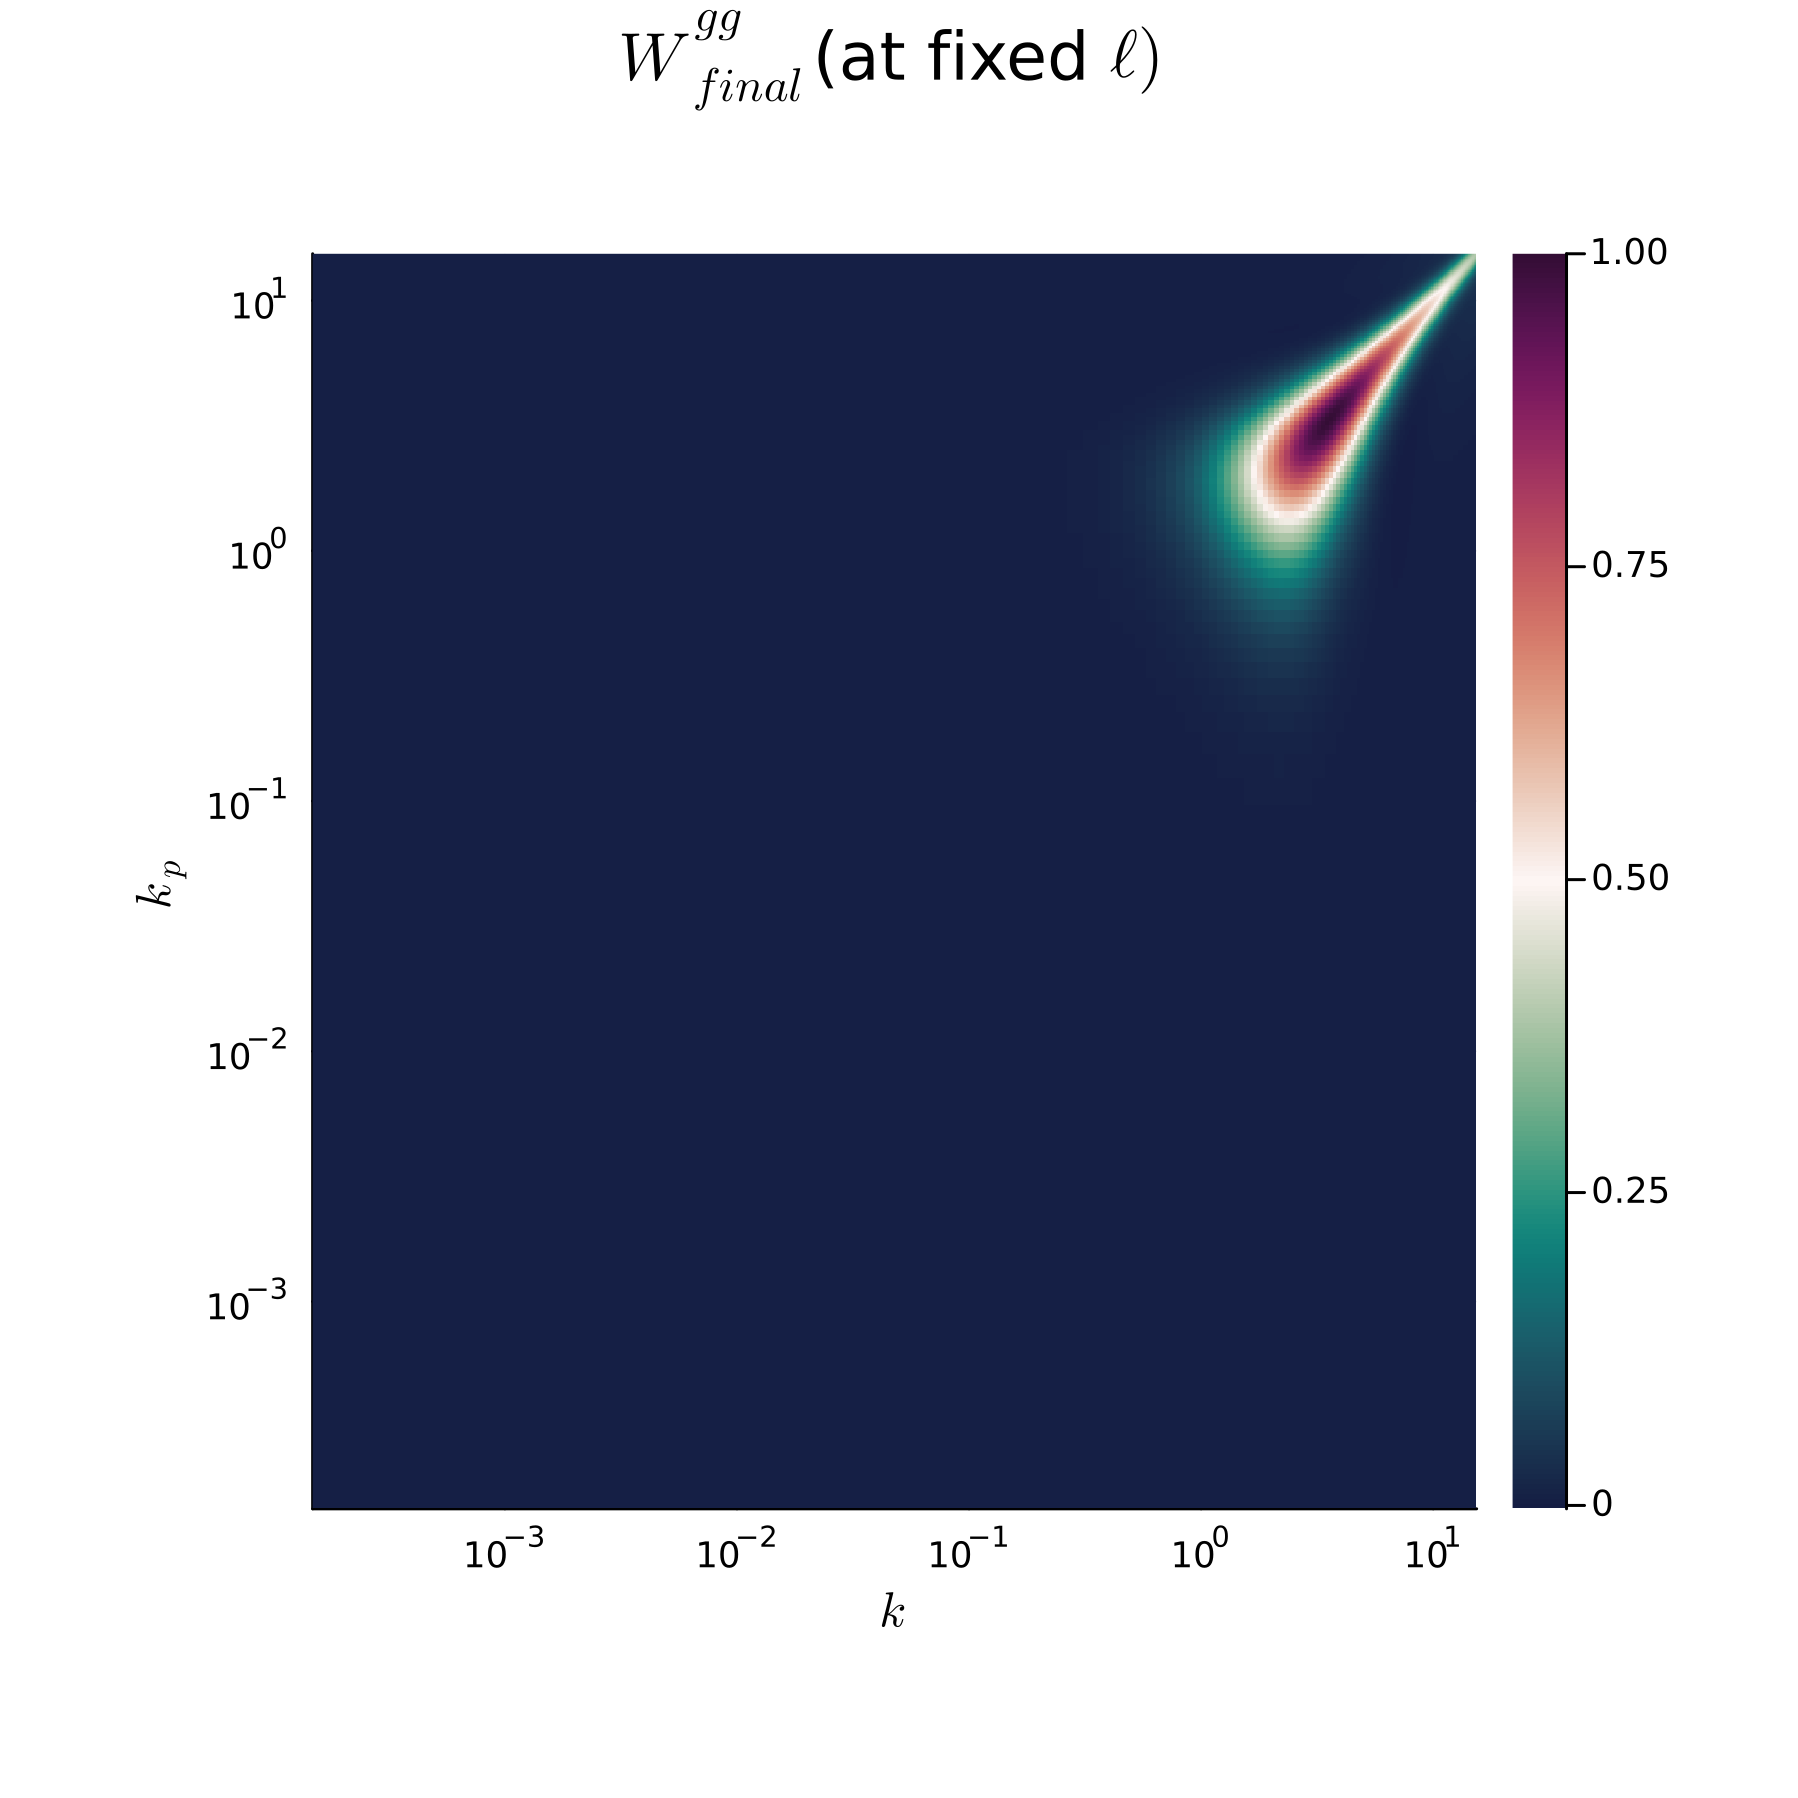

In [36]:
# genera tick automatici alle potenze di 10 nel range dei dati
xticks_vals = 10.0 .^ (floor(log10(minimum(grids.k_grid))):ceil(log10(maximum(grids.k_grid))))
yticks_vals = 10.0 .^ (floor(log10(minimum(grids.kp_grid))):ceil(log10(maximum(grids.kp_grid))))

heatmap(grids.k_grid[idx], grids.kp_grid[idx_p],
        W_final_gal[1,idx,idx_p]/maximum(W_final_gal[1,idx,idx_p]),
        title=L"W_{final}^{gg}"*"(at fixed "*L"ℓ)",
        xscale = :log10, yscale = :log10,
        xlabel=L"k", ylabel=L"k_p",
        size = plot_theme.size_heatmap,
        c = plot_theme.c, 
        xticks = xticks_vals, yticks = yticks_vals; plot_theme.shared_style...
        )

In [37]:
savefig(joinpath(paths.plot_subdir, "Sl_plots/heatmap_k_k1.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_15_103319/plots/Sl_plots/heatmap_k_k1.png"

In [38]:
println(size(W_tilde))

(150, 150, 200, 100)


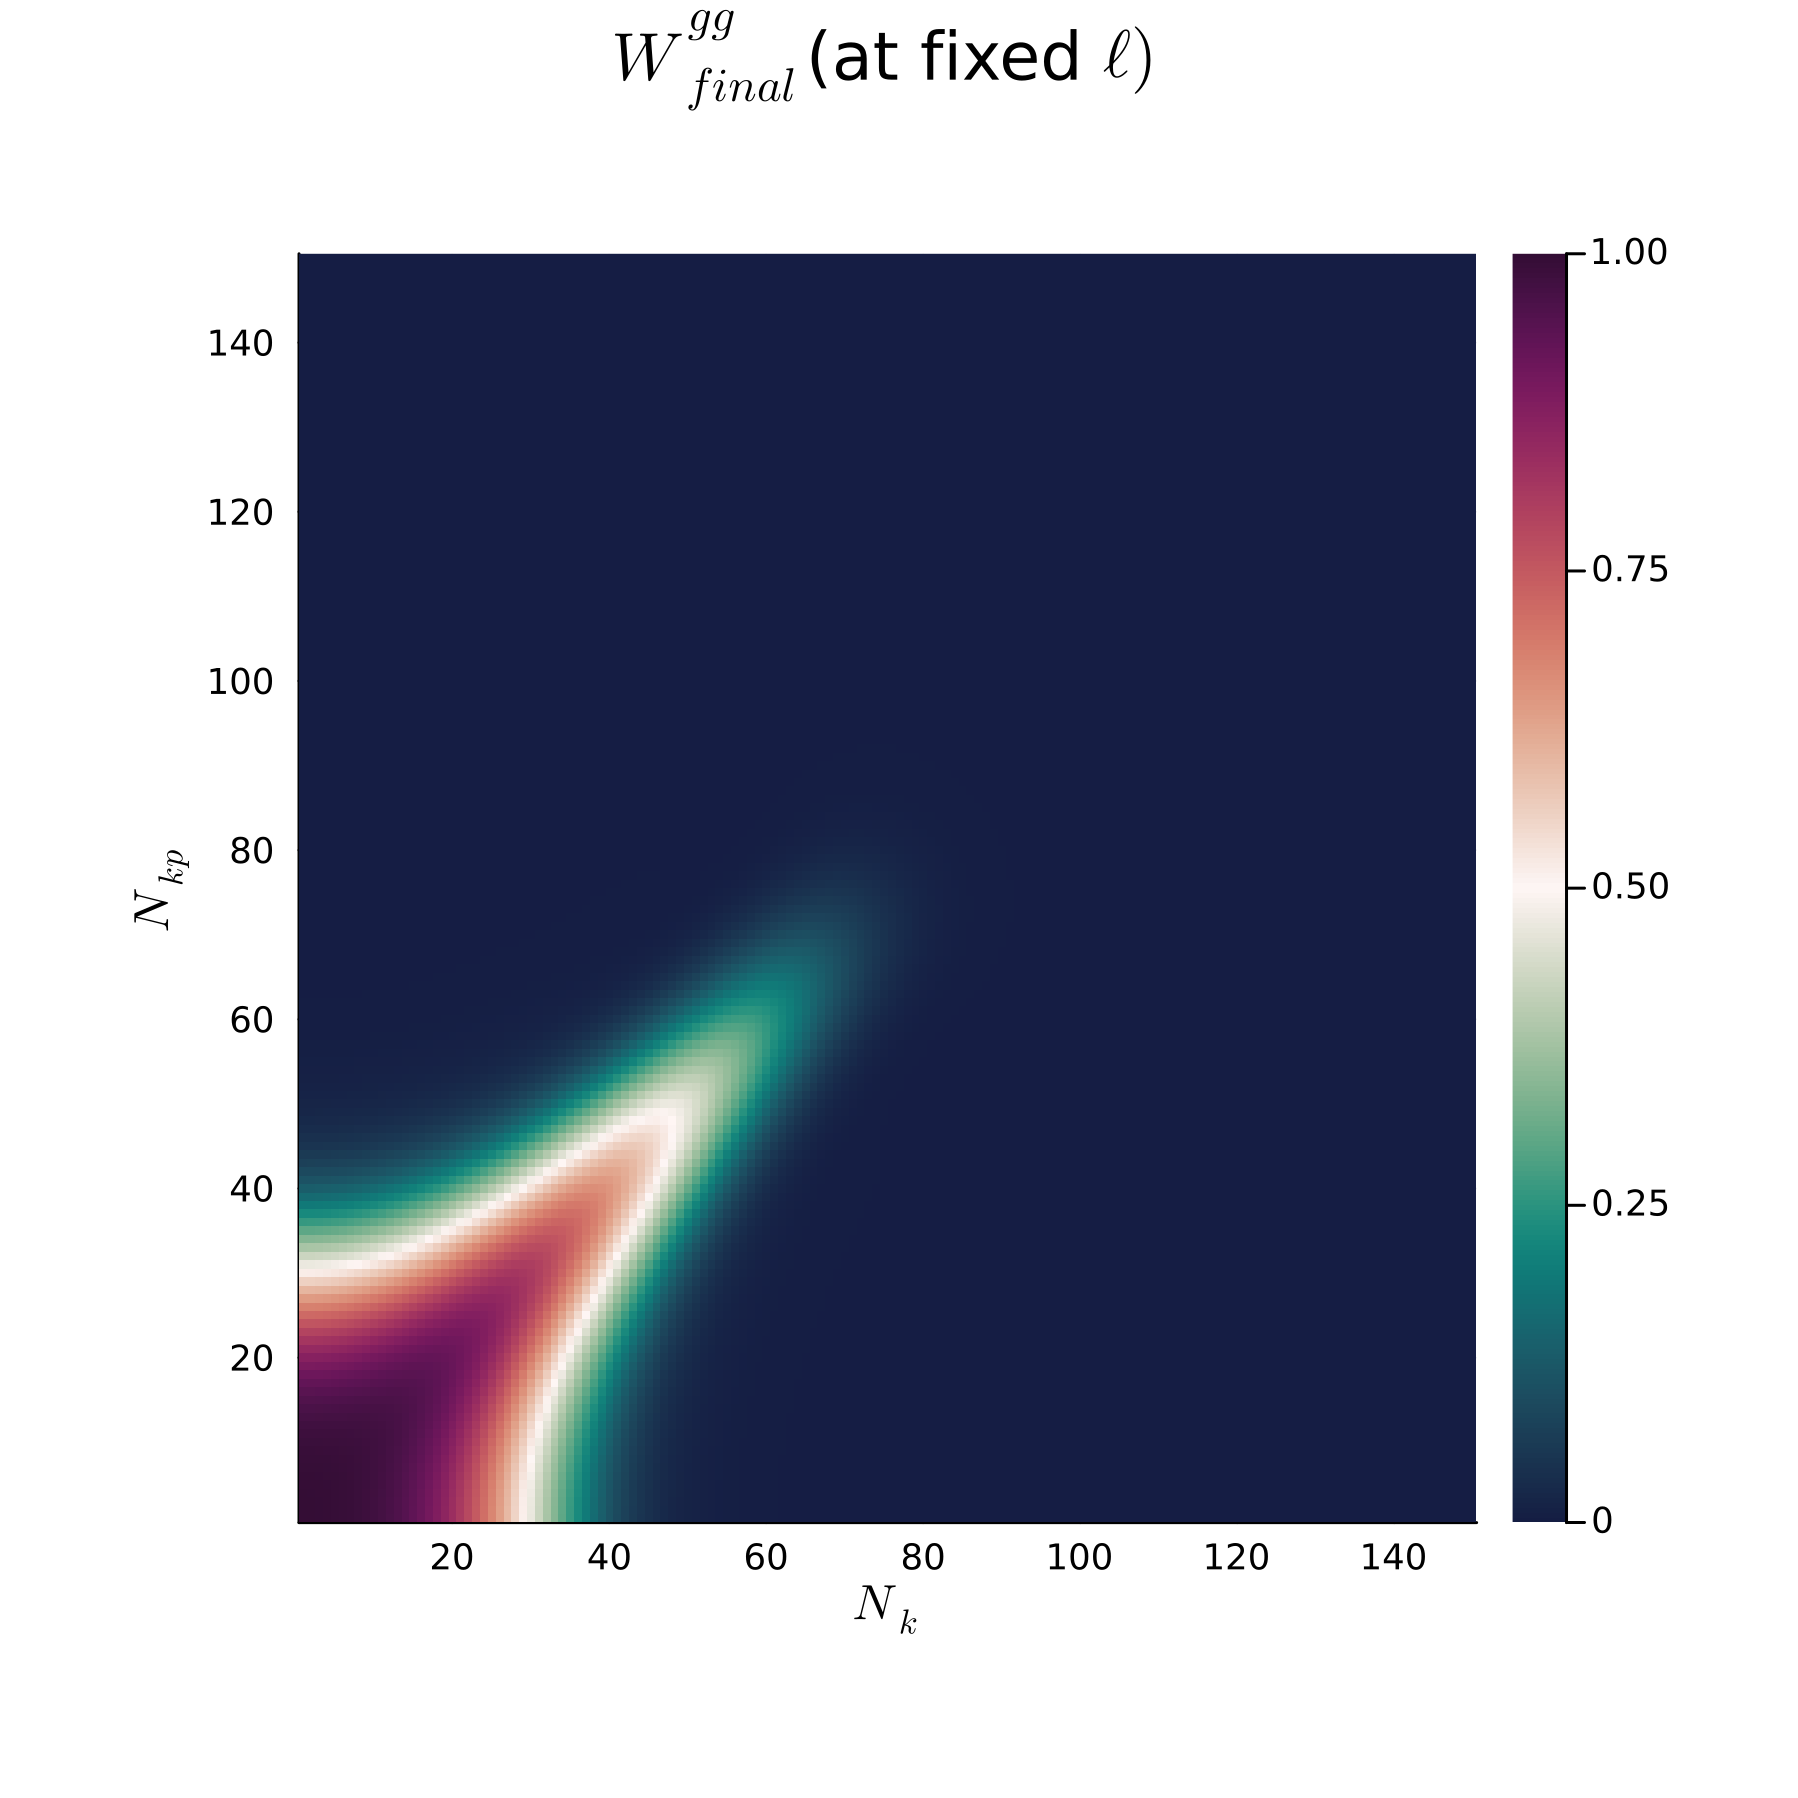

In [39]:
heatmap(1:grid_data.Nk, 1:grid_data.Nkp, W_final_gal[10,:,:]/maximum(W_final_gal[10,:,:]), 
    title = L"W_{final}^{gg}"*"(at fixed "*L"ℓ)", 
    xlabel = L"N_k", ylabel = L"N_{kp}", 
    colorbar = true, c = plot_theme.c, size = plot_theme.size_heatmap; plot_theme.shared_style...
    )


In [40]:
savefig(joinpath(paths.plot_subdir, "Sl_plots/heatmap_Nk_Nkp.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_15_103319/plots/Sl_plots/heatmap_Nk_Nkp.png"

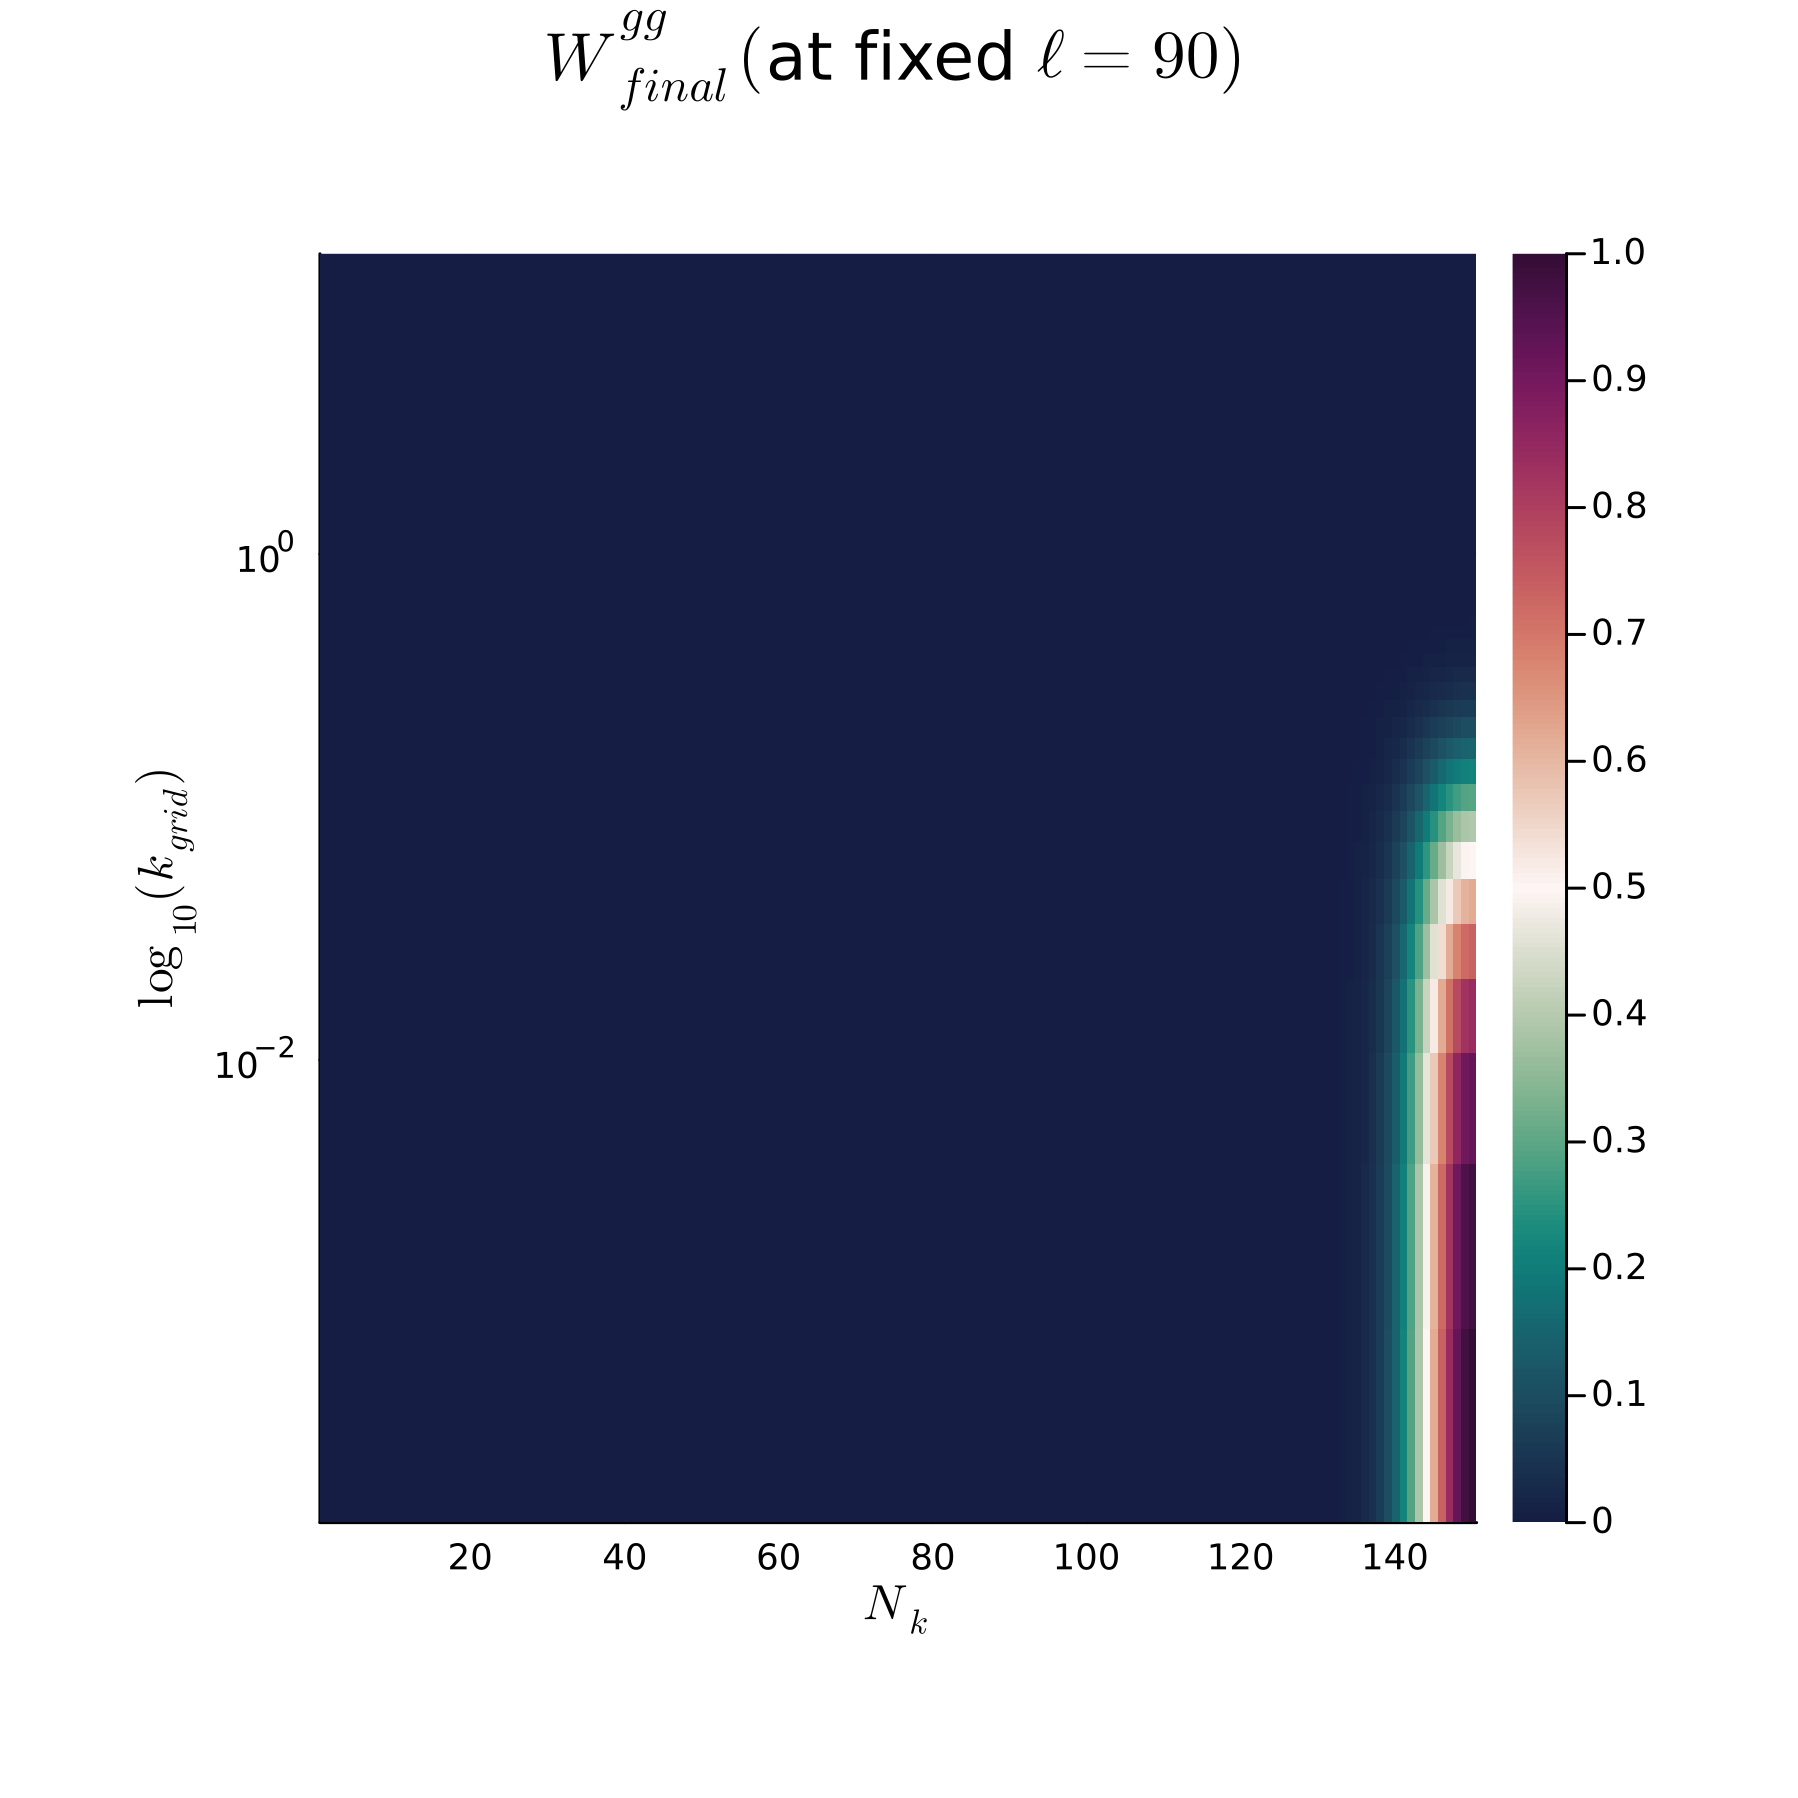

In [41]:
yticks_vals = 10.0 .^ (floor(log10(minimum(grids.k_grid))):ceil(log10(maximum(grids.k_grid))))
heatmap(1:grid_data.Nk, 
        grids.kp_grid[idx_p], 
        W_final_gal[90, :, idx_p] / maximum(W_final_gal[90, :, idx_p]), 
        title = L"W_{final}^{gg}"*L"("*"at fixed "*L"ℓ = 90)", 
        xlabel = L"N_k", ylabel = L"\log_{10}(k_{grid})",
        yscale = :log10, colorbar = true, c = plot_theme.c, size = plot_theme.size_heatmap; plot_theme.shared_style...
        )


In [42]:
savefig(joinpath(paths.plot_subdir, "Sl_plots/heatmap_Nk_kp.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_15_103319/plots/Sl_plots/heatmap_Nk_kp.png"

In [43]:
#3D matter power spectrum
pk_dict = npzread("blast_code/data/pk.npz")
Pklin = pk_dict["pk_lin"]
Pknonlin = pk_dict["pk_nl"]
k_pk = pk_dict["k"]
z_pk = pk_dict["z"]
#Interpolating the power spectrum: Linear P(k) - Non-linear P(k)
y_pk = LinRange(log10(first(k_pk)),log10(last(k_pk)), length(k_pk))
x_pk = LinRange(first(z_pk), last(z_pk), length(z_pk))
InterpPmm = Interpolations.interpolate(log10.(Pklin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm = scale(InterpPmm, (x_pk, y_pk))
InterpPmm = Interpolations.extrapolate(InterpPmm, Line())
InterpPmm_nl = Interpolations.interpolate(log10.(Pknonlin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm_nl = scale(InterpPmm_nl, x_pk, y_pk)
InterpPmm_nl = Interpolations.extrapolate(InterpPmm_nl, Line())
power_spectrum(k_pk, χ1, χ2) = @. sqrt(10^InterpPmm(grid_data.z_of_χ(χ1),log10(k_pk)) * 10^InterpPmm(grid_data.z_of_χ(χ2),log10(k_pk)))
power_spectrum_nl(k_pk, χ1, χ2) = @. sqrt(10^InterpPmm_nl(grid_data.z_of_χ(χ1),log10(k_pk)) * 10^InterpPmm_nl(grid_data.z_of_χ(χ2),log10(k_pk)))

power_spectrum_nl (generic function with 1 method)

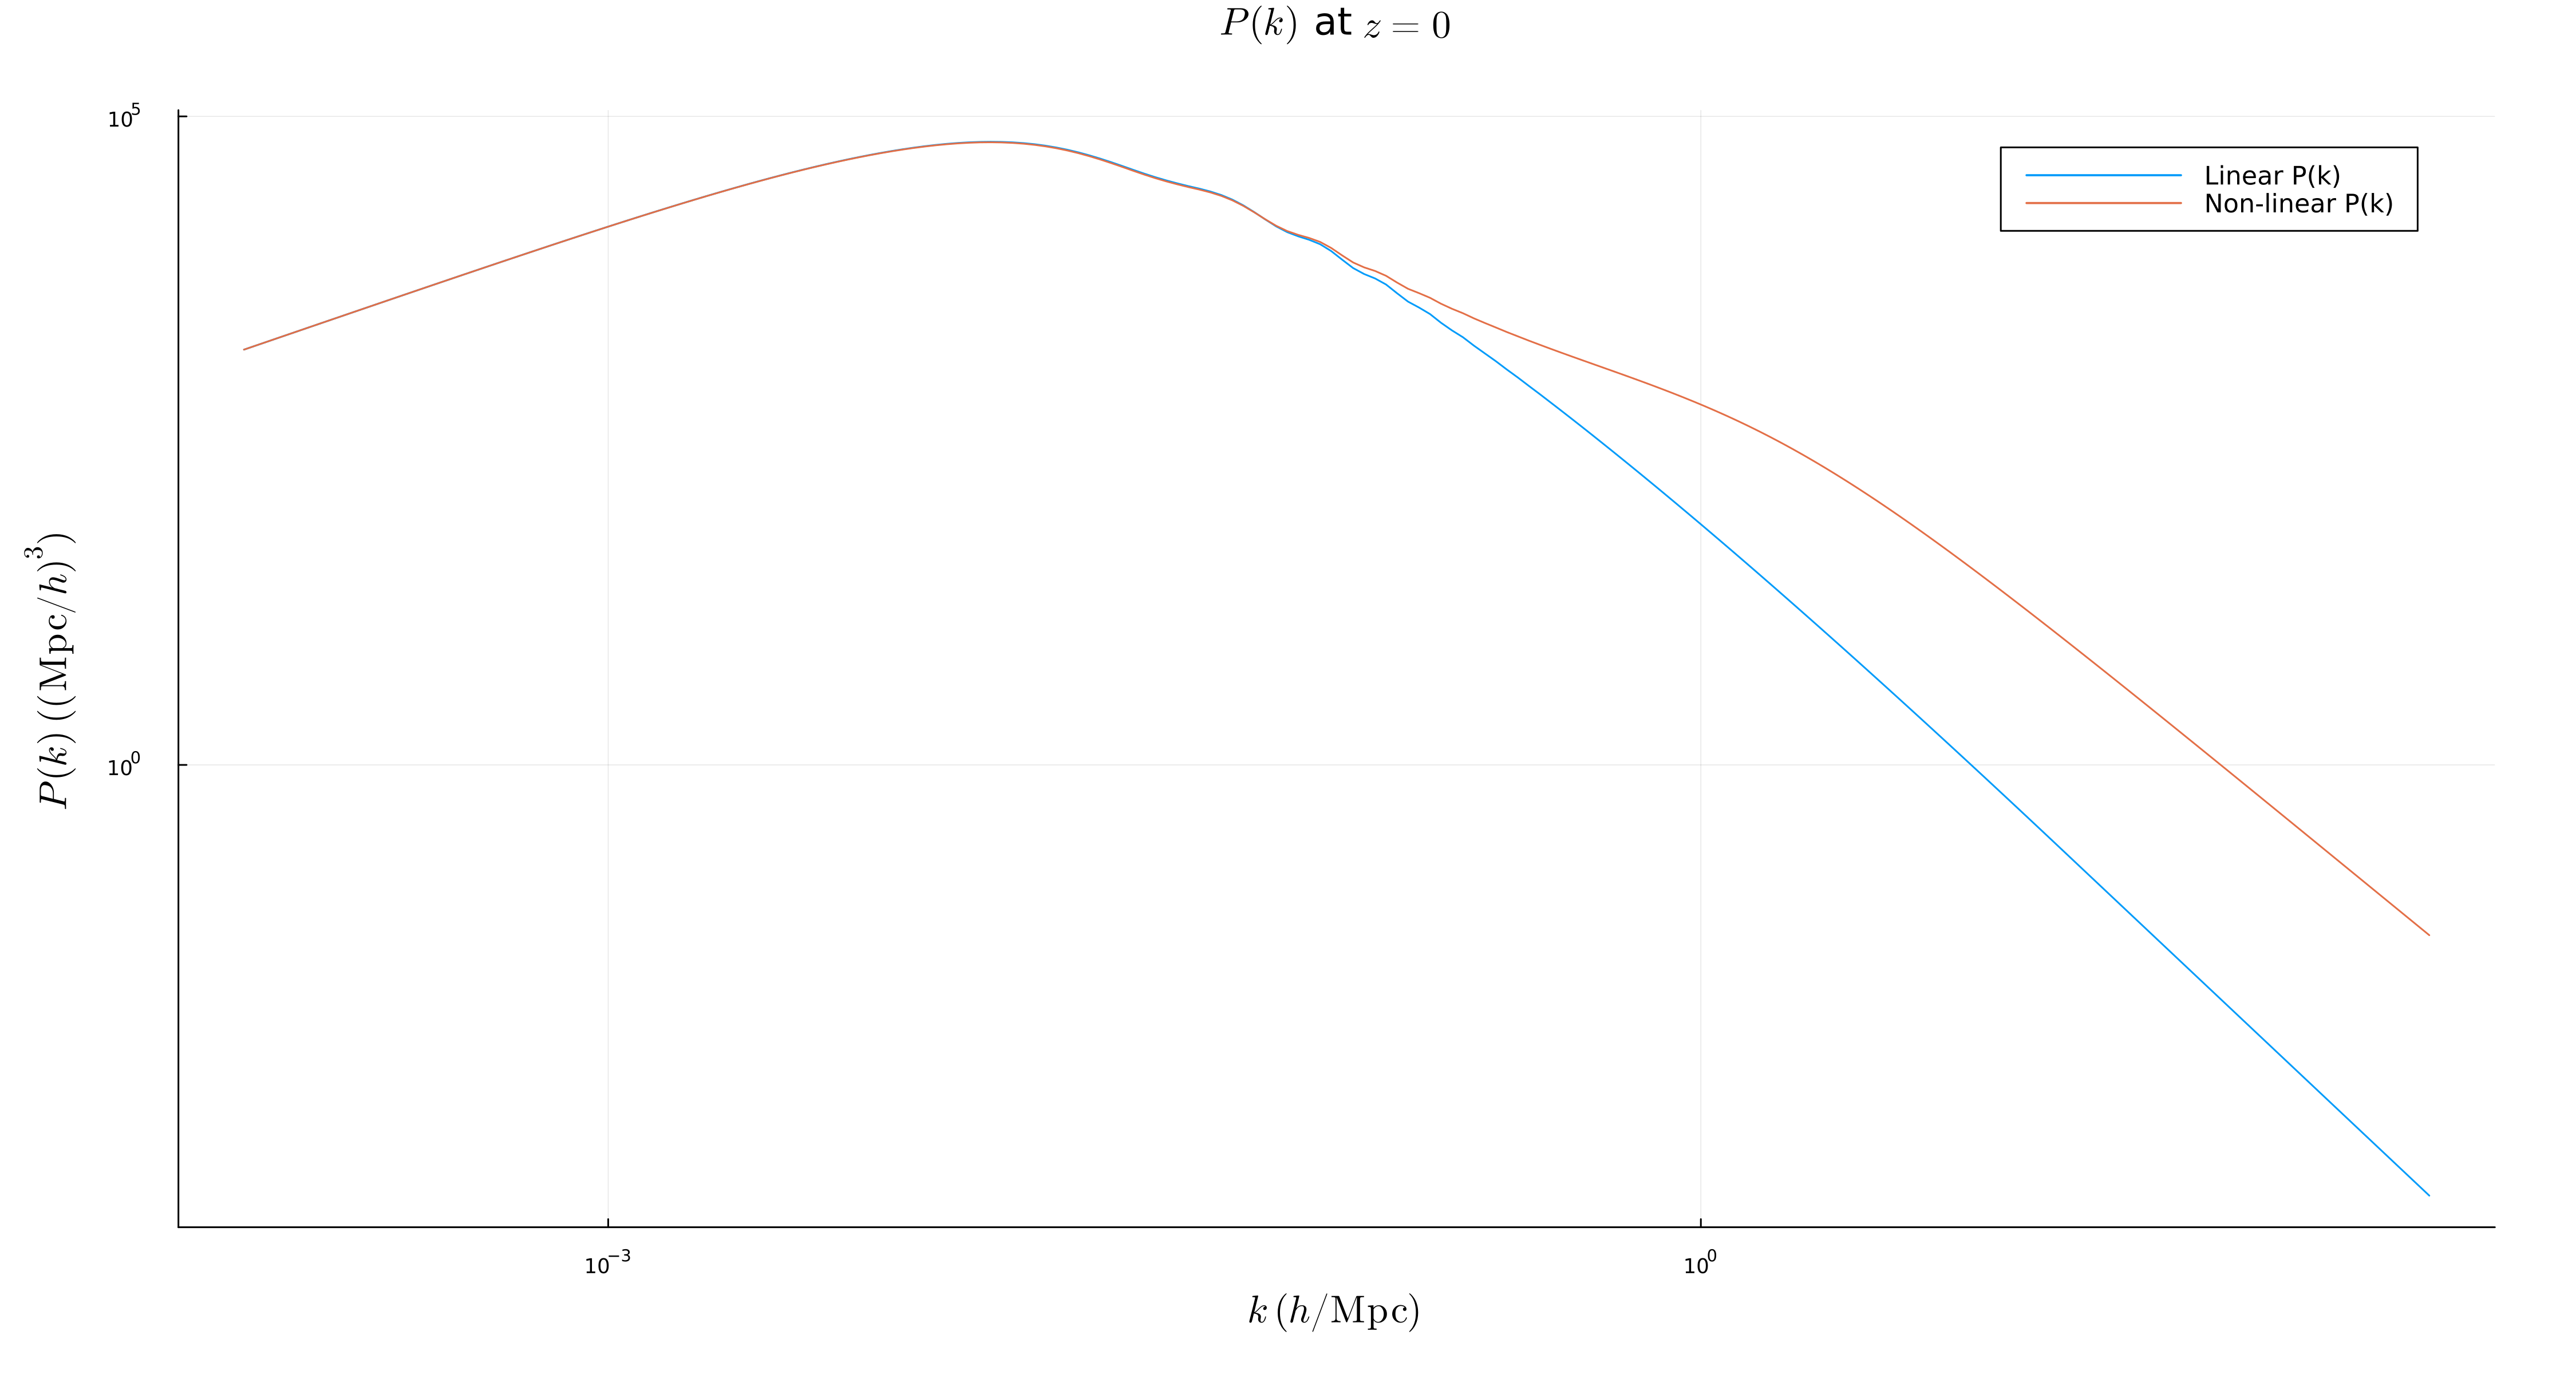

In [44]:
plot(k_pk, power_spectrum.(k_pk, 1000.0, 1000.0), 
     label="Linear P(k)", 
     xscale=:log10, 
     yscale=:log10, 
     title=L"$P(k)$ at $z=0$", titlefontsize=20,
     xlabel=L"$k \; (h/\mathrm{Mpc})$", 
     ylabel=L"$P(k) \; ((\mathrm{Mpc}/h)^3)$", 
     labelfontsize=15)
plot!(k_pk, power_spectrum_nl.(k_pk, 1000.0, 1000.0), 
      label="Non-linear P(k)", 
      xscale=:log10, 
      yscale=:log10, size=plot_theme.size_Cl; plot_theme.shared_style...
      )

get_clencurt_grid produces the node of Clenshaw-Curtis mapped on [$k_{min}$, $k_{max}$]. \
get_clencurt_weights produces the corresponding quadrature weights scaled to the interval [-1,1]. \

In [45]:
Pk_grid = power_spectrum.(grids.k_grid, grid_data.xmin, grid_data.xmax)
npzwrite("/Users/anvi/Desktop/cosmo/notebooks/out/pk_grid.npy", Pk_grid)
w_k = Blast.get_clencurt_weights(grid_data.kmin, grid_data.kmax, grid_data.Nk)
weight_gal = w_k .* grids.k_grid.^2 .* Pk_grid 
;

when plotting C(l) is doesn't matter that I define the plot with a grid in k which is decreasing (like k_grid). In the heatmap on the other hand, the axis must have ordered quantities.

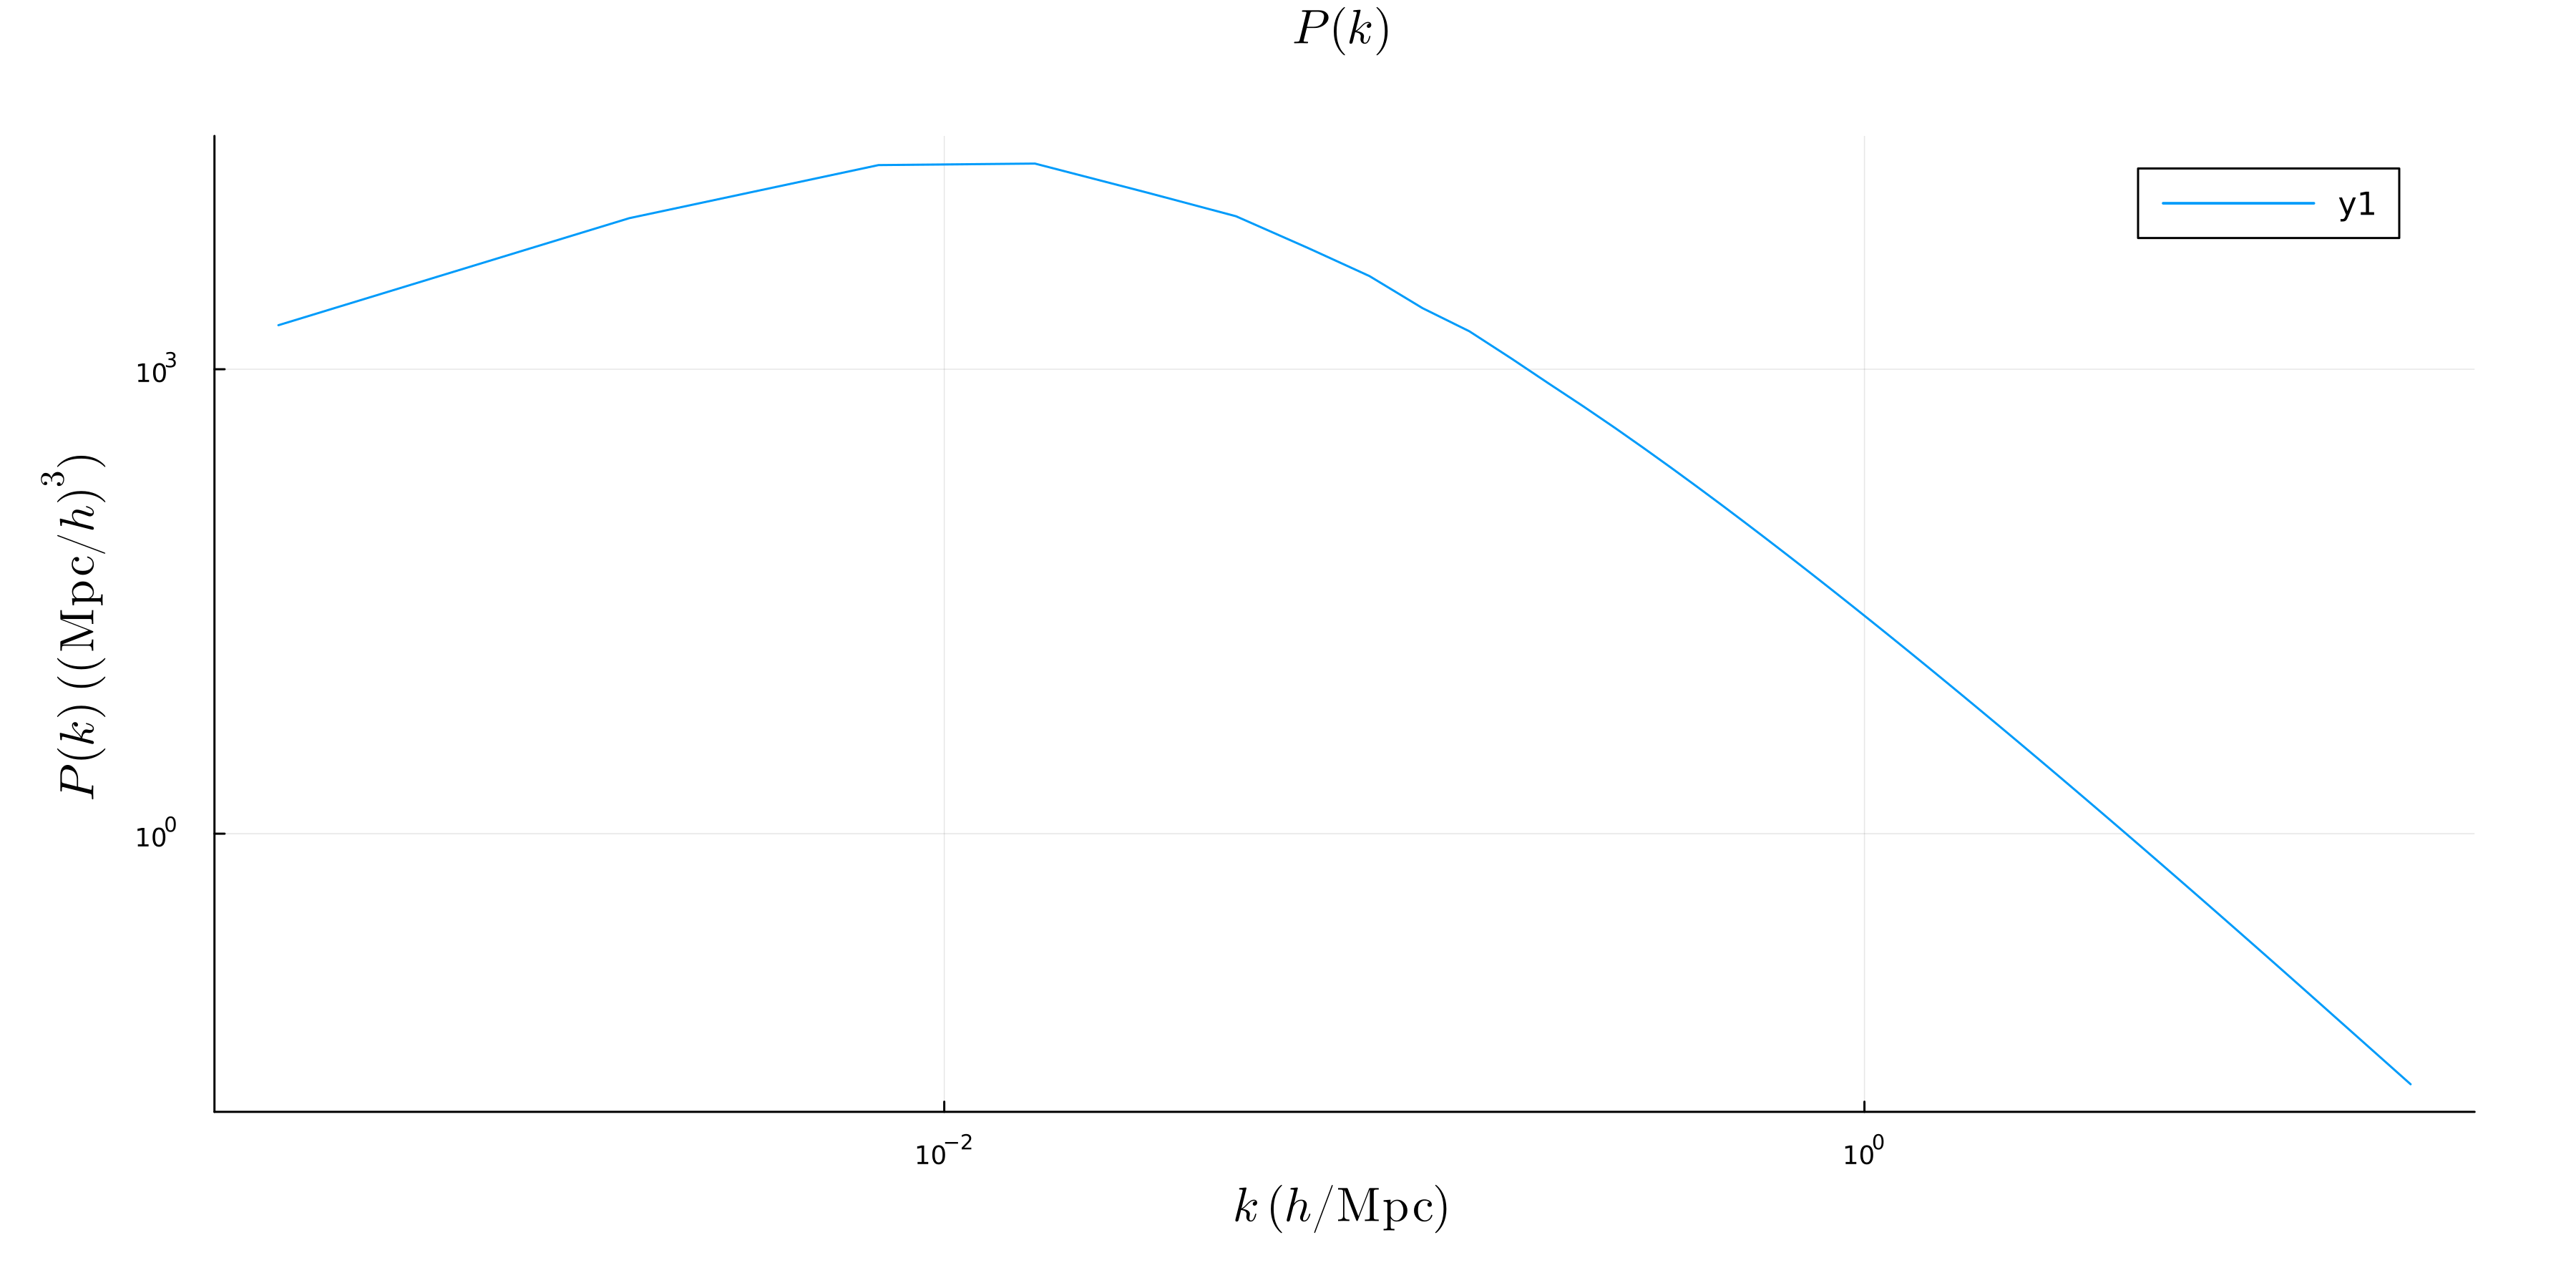

In [46]:
plot(grids.k_grid, Pk_grid, 
     xscale=:log10, 
     yscale=:log10, 
     title=L"$P(k)$", titlefontsize=20,
     xlabel=L"$k \; (h/\mathrm{Mpc})$", 
     ylabel=L"$P(k) \; ((\mathrm{Mpc}/h)^3)$", 
     labelfontsize=15, size=plot_theme.size_plot; plot_theme.shared_style...
     )

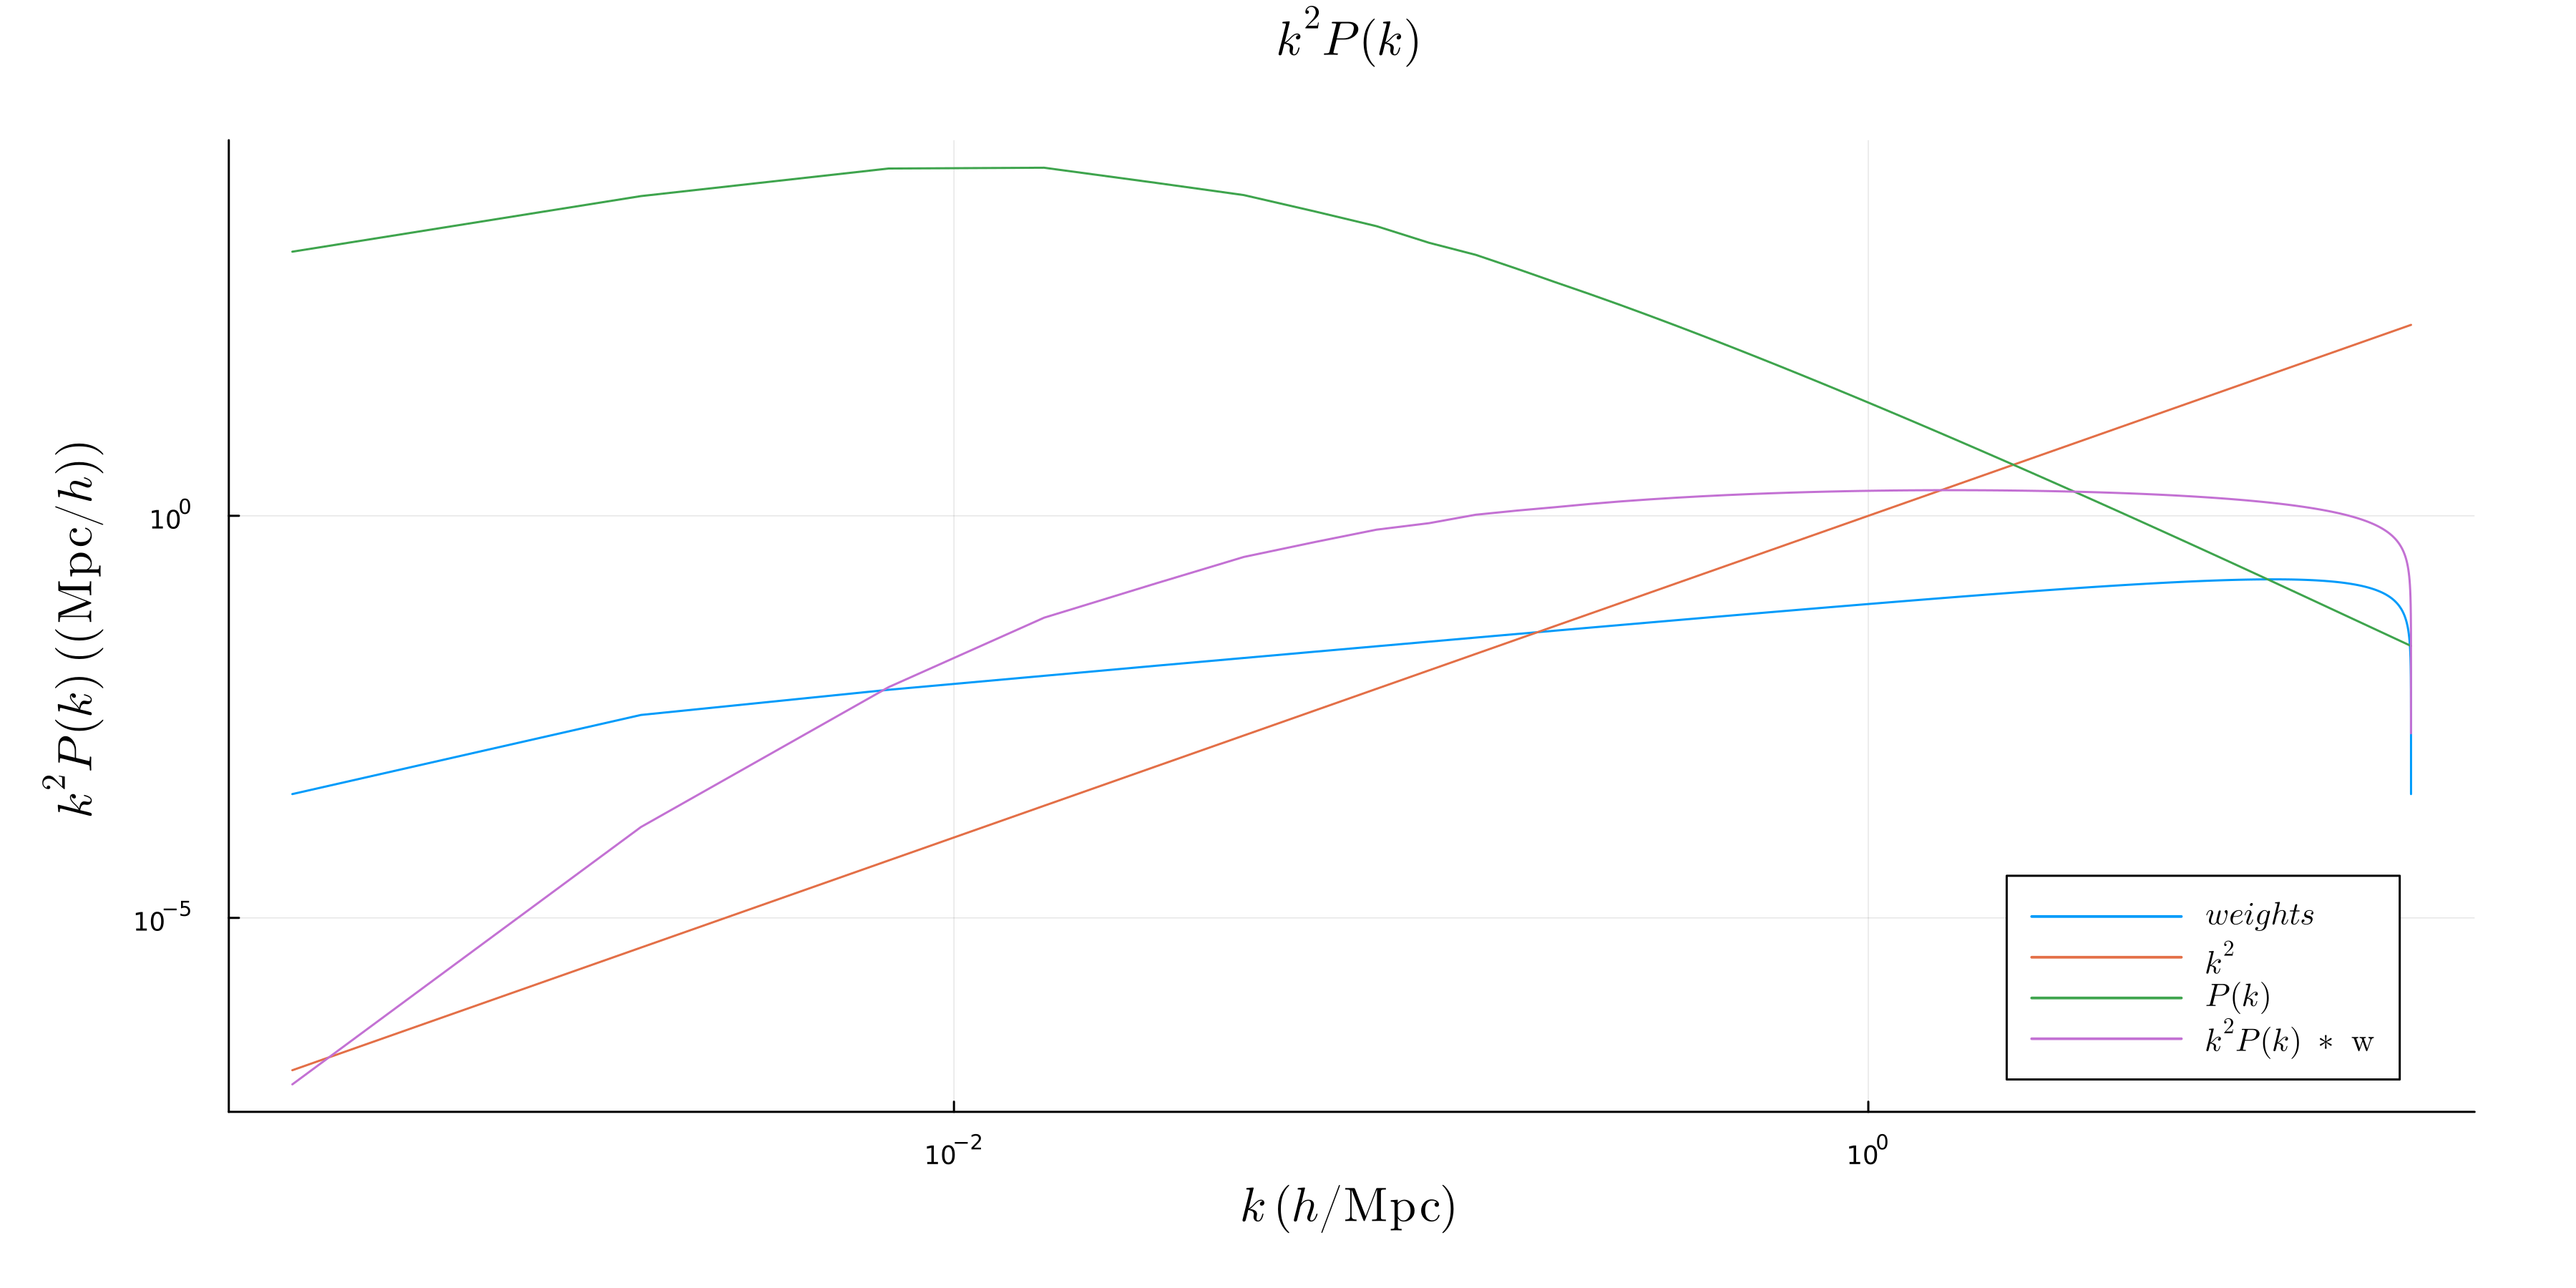

In [47]:
plot(grids.k_grid, w_k, label = L"weights", xscale = :log10, 
     yscale = :log10, 
     xlabel = L"k \; (h/\mathrm{Mpc})", size=plot_theme.size_Cl; plot_theme.shared_style...
     )
plot!(grids.k_grid, grids.k_grid.^2, label = L"k^2", xscale = :log10, 
     yscale = :log10, 
     xlabel = L"k \; (h/\mathrm{Mpc})", size=plot_theme.size_Cl; plot_theme.shared_style...
     )
plot!(grids.k_grid, Pk_grid, label = L"P(k)", xscale = :log10, 
     yscale = :log10, 
     xlabel = L"k \; (h/\mathrm{Mpc})", size=plot_theme.size_Cl; plot_theme.shared_style...
     )
plot!(grids.k_grid, weight_gal, 
     xscale=:log10, 
     yscale=:log10, 
     title=L"$k^2 P(k)$", titlefontsize=20,
     xlabel=L"$k \; (h/\mathrm{Mpc})$", 
     ylabel=L"$k^2 P(k) \; ((\mathrm{Mpc}/h))$", 
     label =L"$k^2 P(k) \; * \; \mathrm{w} $",
     labelfontsize=15, legendposition = :bottomright, size=plot_theme.size_plot; plot_theme.shared_style...
     )

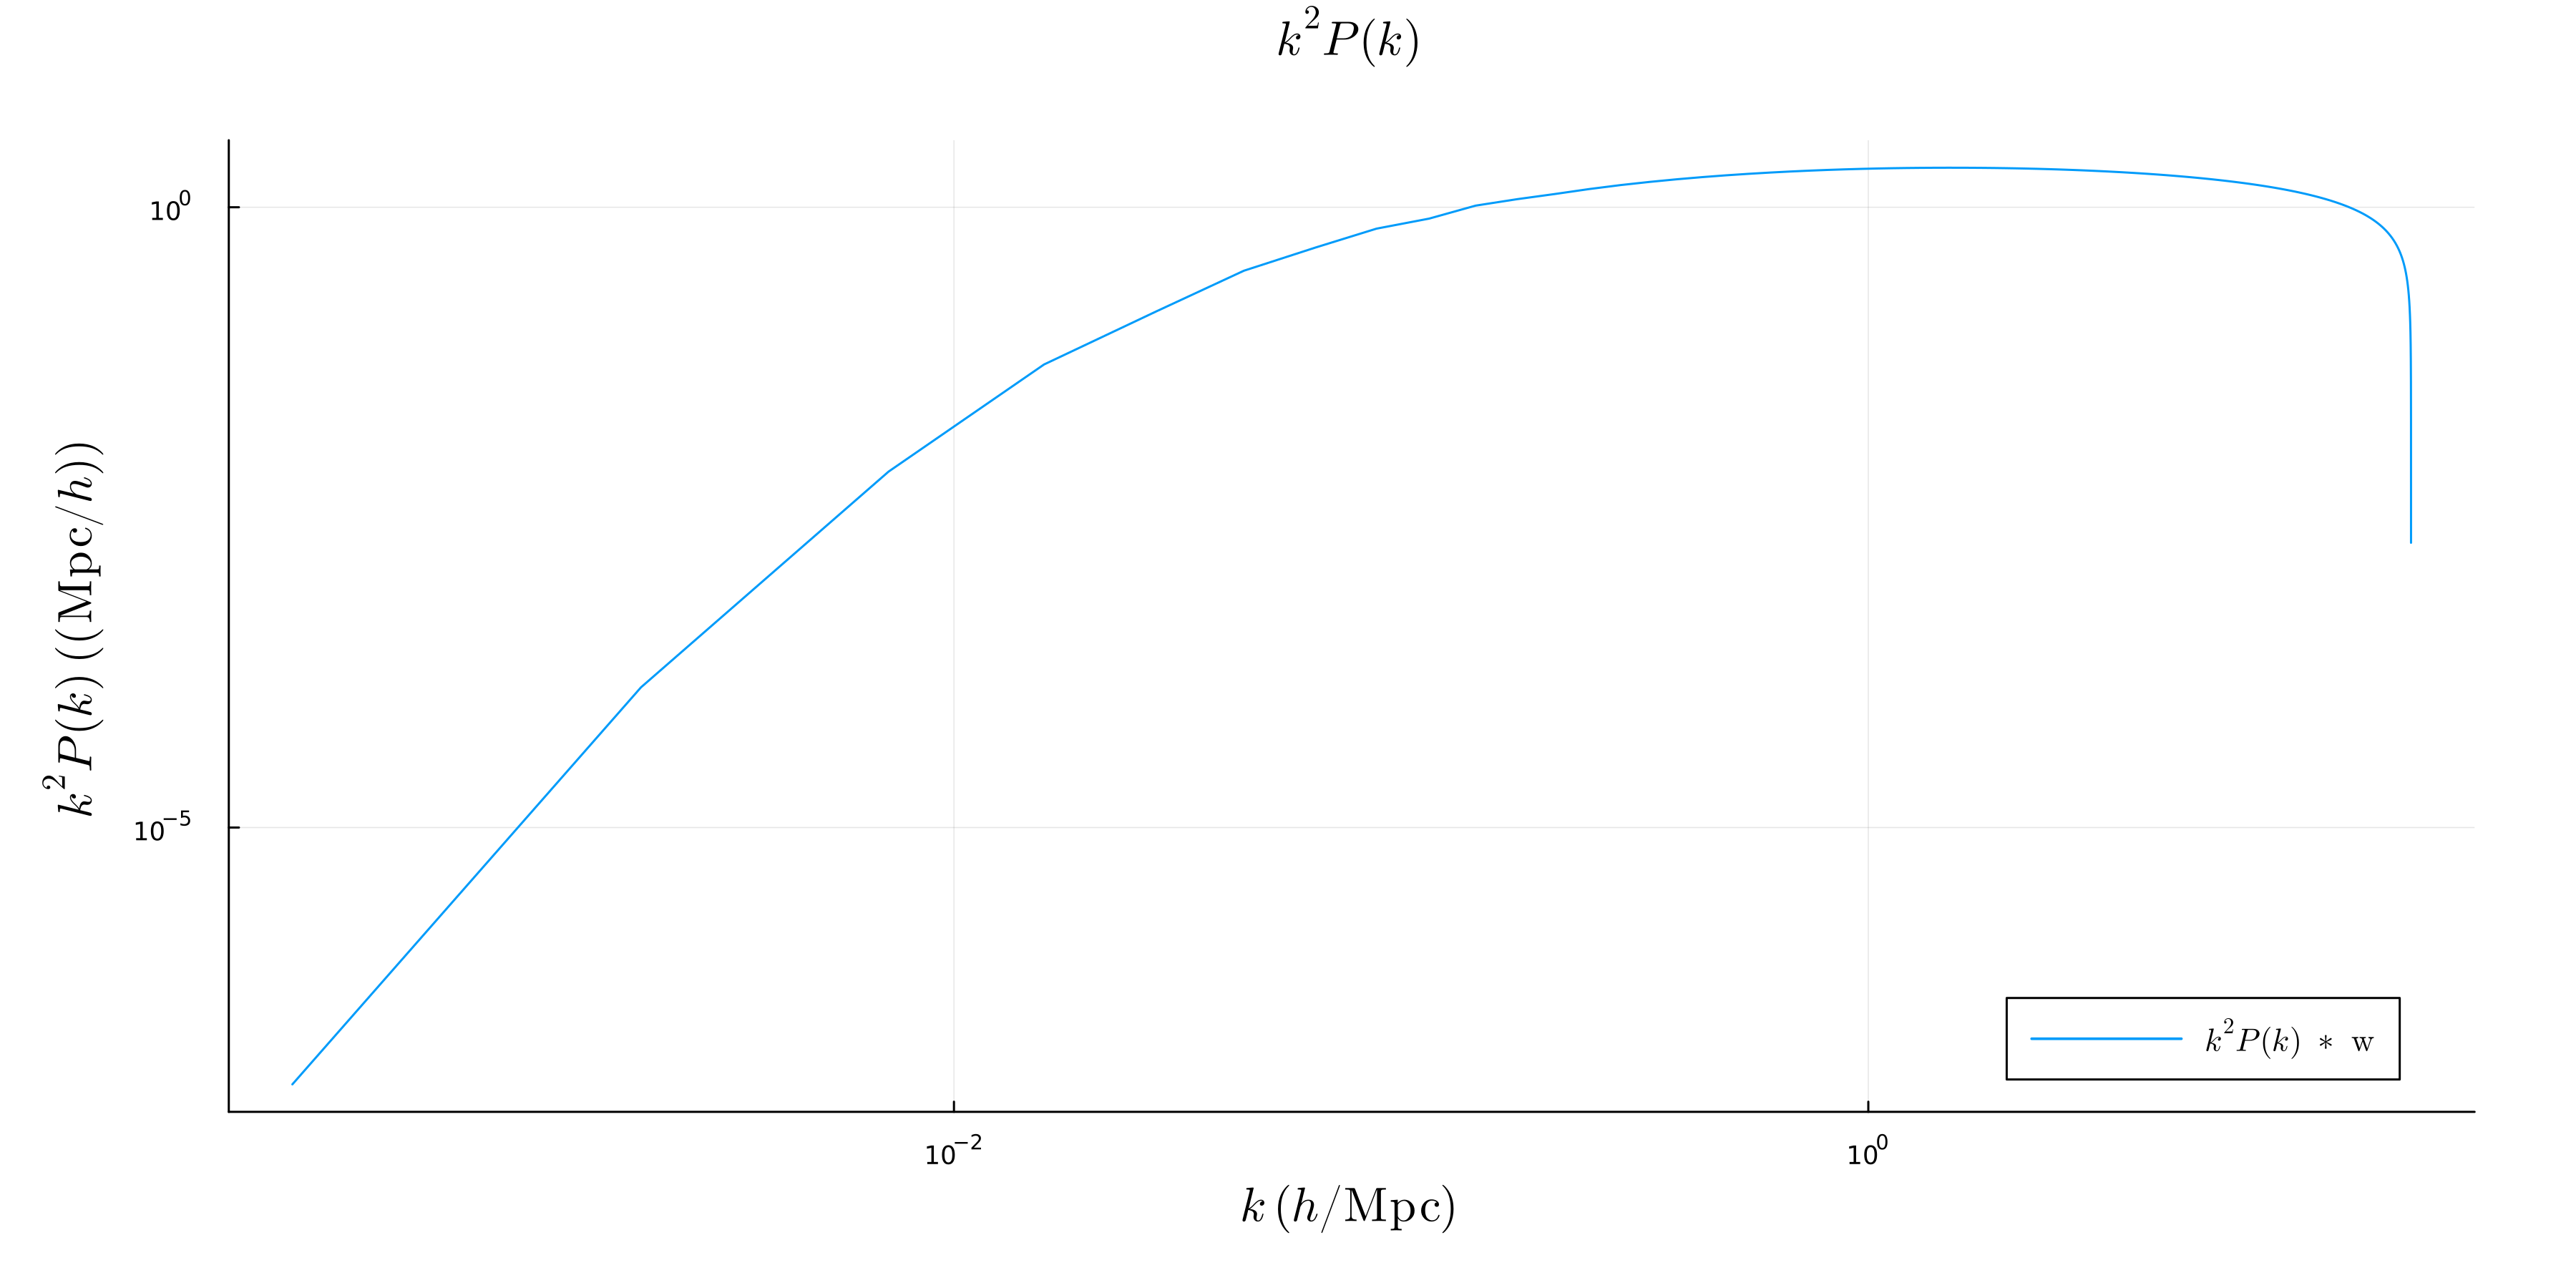

In [48]:
plot(grids.k_grid, weight_gal, 
     xscale=:log10, 
     yscale=:log10, 
     title=L"$k^2 P(k)$", titlefontsize=20,
     xlabel=L"$k \; (h/\mathrm{Mpc})$", 
     ylabel=L"$k^2 P(k) \; ((\mathrm{Mpc}/h))$", 
     label =L"$k^2 P(k) \; * \; \mathrm{w} $",
     labelfontsize=15, legendposition = :bottomright, size=plot_theme.size_plot; plot_theme.shared_style...
     )

In [49]:
abstract type AbstractProbe end
struct Galaxy <: AbstractProbe end
struct Shear <: AbstractProbe end
factorial_frac(ℓ) = (ℓ + 2.0) * (ℓ + 1.0) * ℓ * (ℓ - 1.0)
get_ell_prefactor(::Galaxy, ::Galaxy, ℓ) = @. (2 / π) * ones(length(ℓ))
get_ell_prefactor(::Galaxy, ::Shear,  ℓ) = @. (2 / π) * sqrt(factorial_frac(ℓ))
get_ell_prefactor(::Shear,  ::Galaxy, ℓ) = @. (2 / π) * sqrt(factorial_frac(ℓ))
get_ell_prefactor(::Shear,  ::Shear,  ℓ) = @. (2 / π) * factorial_frac(ℓ)
pref_gg = get_ell_prefactor(Galaxy(), Galaxy(), grid_data.ℓ)
pref_gg = reduce(vcat, pref_gg)
pref_gs = get_ell_prefactor(Galaxy(), Shear(), grid_data.ℓ)
pref_gs = reduce(vcat, pref_gs)
pref_gg = reduce(vcat, pref_gg)
pref_ss = get_ell_prefactor(Shear(), Shear(), grid_data.ℓ)
pref_ss = reduce(vcat, pref_ss);

In [50]:
println("SIZES")
println("weight_gal -> ", size(weight_gal))
println("W_final_gal -> ", size(W_final_gal))
println("pref_gg -> ", size(pref_gg))

SIZES
weight_gal -> (150,)
W_final_gal -> (100, 150, 150)
pref_gg -> (100,)


In [87]:
S_lkk_gg = zeros(Float64, size(W_final_gal, 3), size(W_final_gal, 3), length(grid_data.ℓ))
@tullio S_lkk_gg[kp, kpp, li] = pref_gg[li] * weight_gal[k] * W_final_gal[li, k, kp] * W_final_gal[li, k, kpp]
npzwrite(joinpath(paths.quantity_subdir, "Sl/S_lkk_gg.npy"), S_lkk_gg)
println("Size of S_l (kp, kpp) (gal-gal): \n(grid_data.Nk, grid_data.Nkp, NL) -> ", size(S_lkk_gg))
;

Size of S_l (kp, kpp) (gal-gal): 
(grid_data.Nk, grid_data.Nkp, NL) -> (150, 150, 100)


wavenumber k as a function of $\ell$ through $k \approx \frac{\ell+0.5}{\chi}$ ?

In [88]:
npzwrite(joinpath(paths.quantity_subdir, "Sl/S_lkk_gg.npy"), S_lkk_gg)

In [89]:
xref = (grid_data.xmax - grid_data.xmin ) * 0.5
ℓ_to_k = ℓ -> ℓ ./ xref
ℓ_ticks = 1:50:200
k_ticks = ℓ_to_k.(ℓ_ticks)
k_ticklabels = [string(round(k, digits=3)) for k in k_ticks];

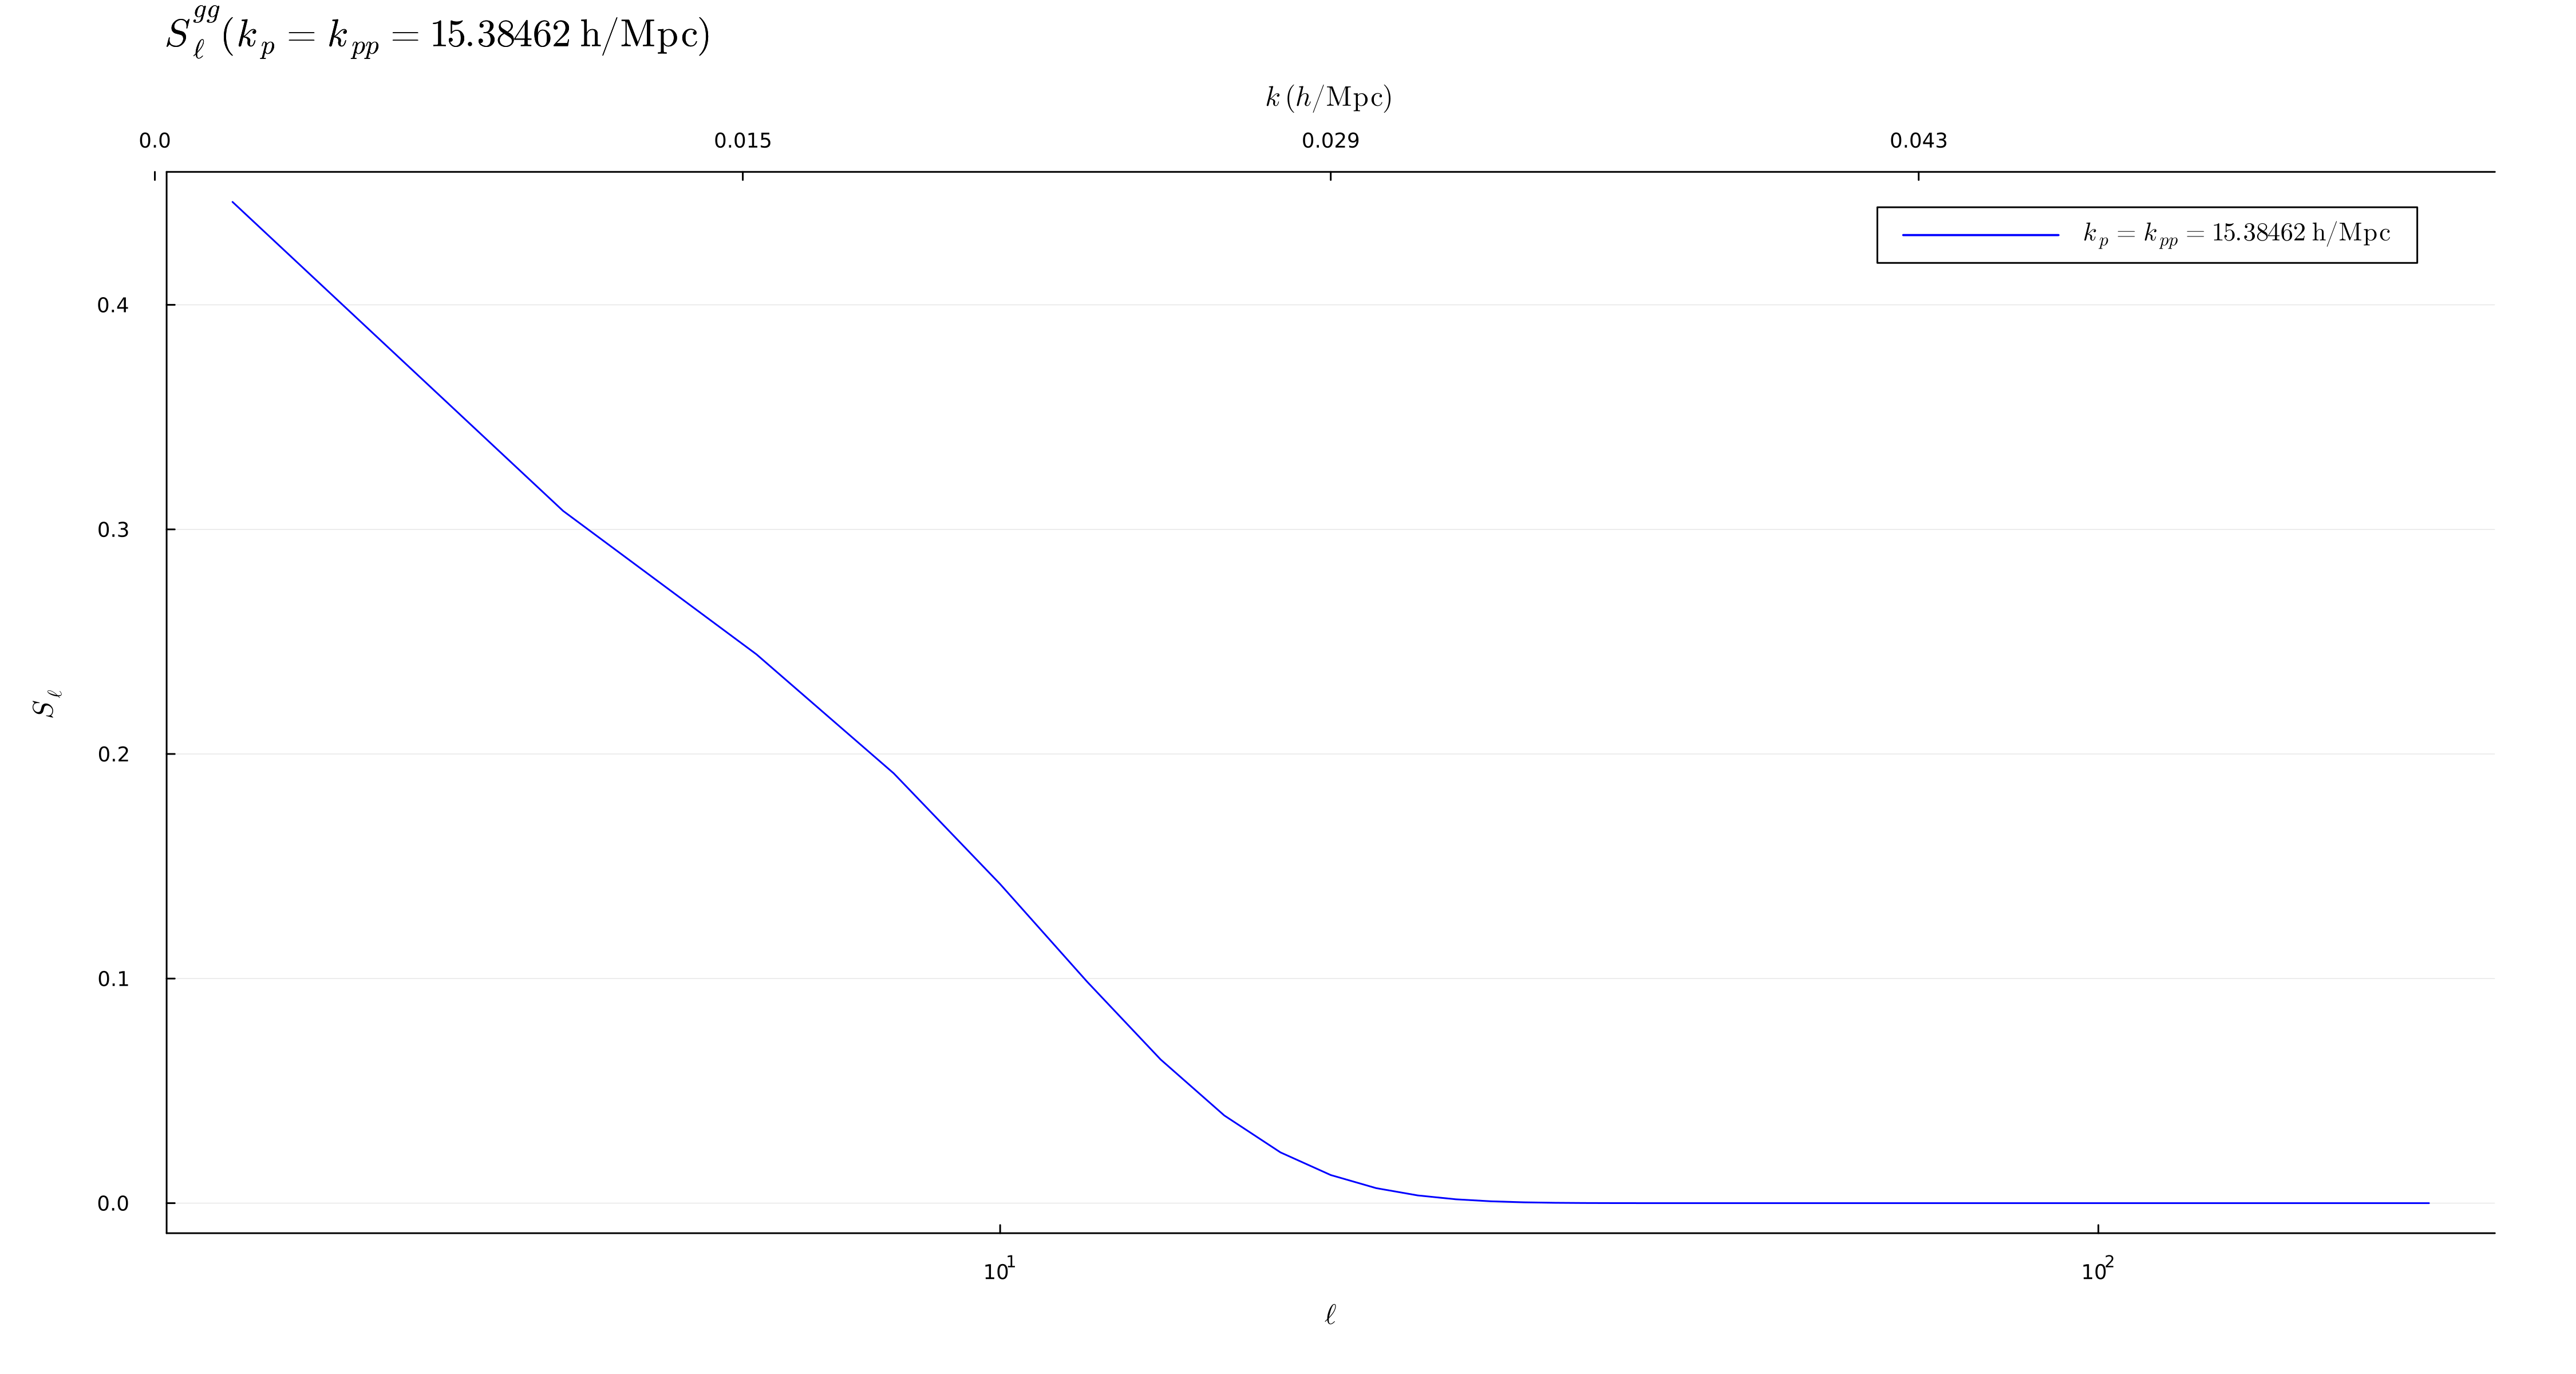

In [90]:
i = 1
j = i 
k_p = grids.k_grid[i]
k_pp = grids.kp_grid[j]
plot(grid_data.ℓ, S_lkk_gg[i,j,:],
      color = :blue,
      label = label = L"k_p = k_{pp} = %$(round(k_p, digits=5)) \; \mathrm{h/Mpc}")
      
plot!(xaxis = L"\ell",
      ylabel = L"S_\ell"
      ,xscale = :log10,
     )
plot!(twiny(),
      xaxis = L"k \; (h/\mathrm{Mpc})",
      xticks = (ℓ_ticks, k_ticklabels),
      #xscale = :log10,
      xlims = (minimum(grid_data.ℓ), maximum(grid_data.ℓ)),
      label = ""
     )
plot!(label = "Beyond BLAST", 
      size=plot_theme.size_Cl,
      title = L"S_{\ell}^{gg} (k_p = k_{pp} = %$(round(k_p, digits=5)) \; \mathrm{h/Mpc})",
      titlefontsize = 20,
      titleposition = :left ; plot_theme.shared_style...)

ℓ = 2.0
ℓ is fixed always
k_1 (k_p) varies at each iteration
k_2 (k_pp) = 14.837259657173398 h/Mpc - fixed, stays there


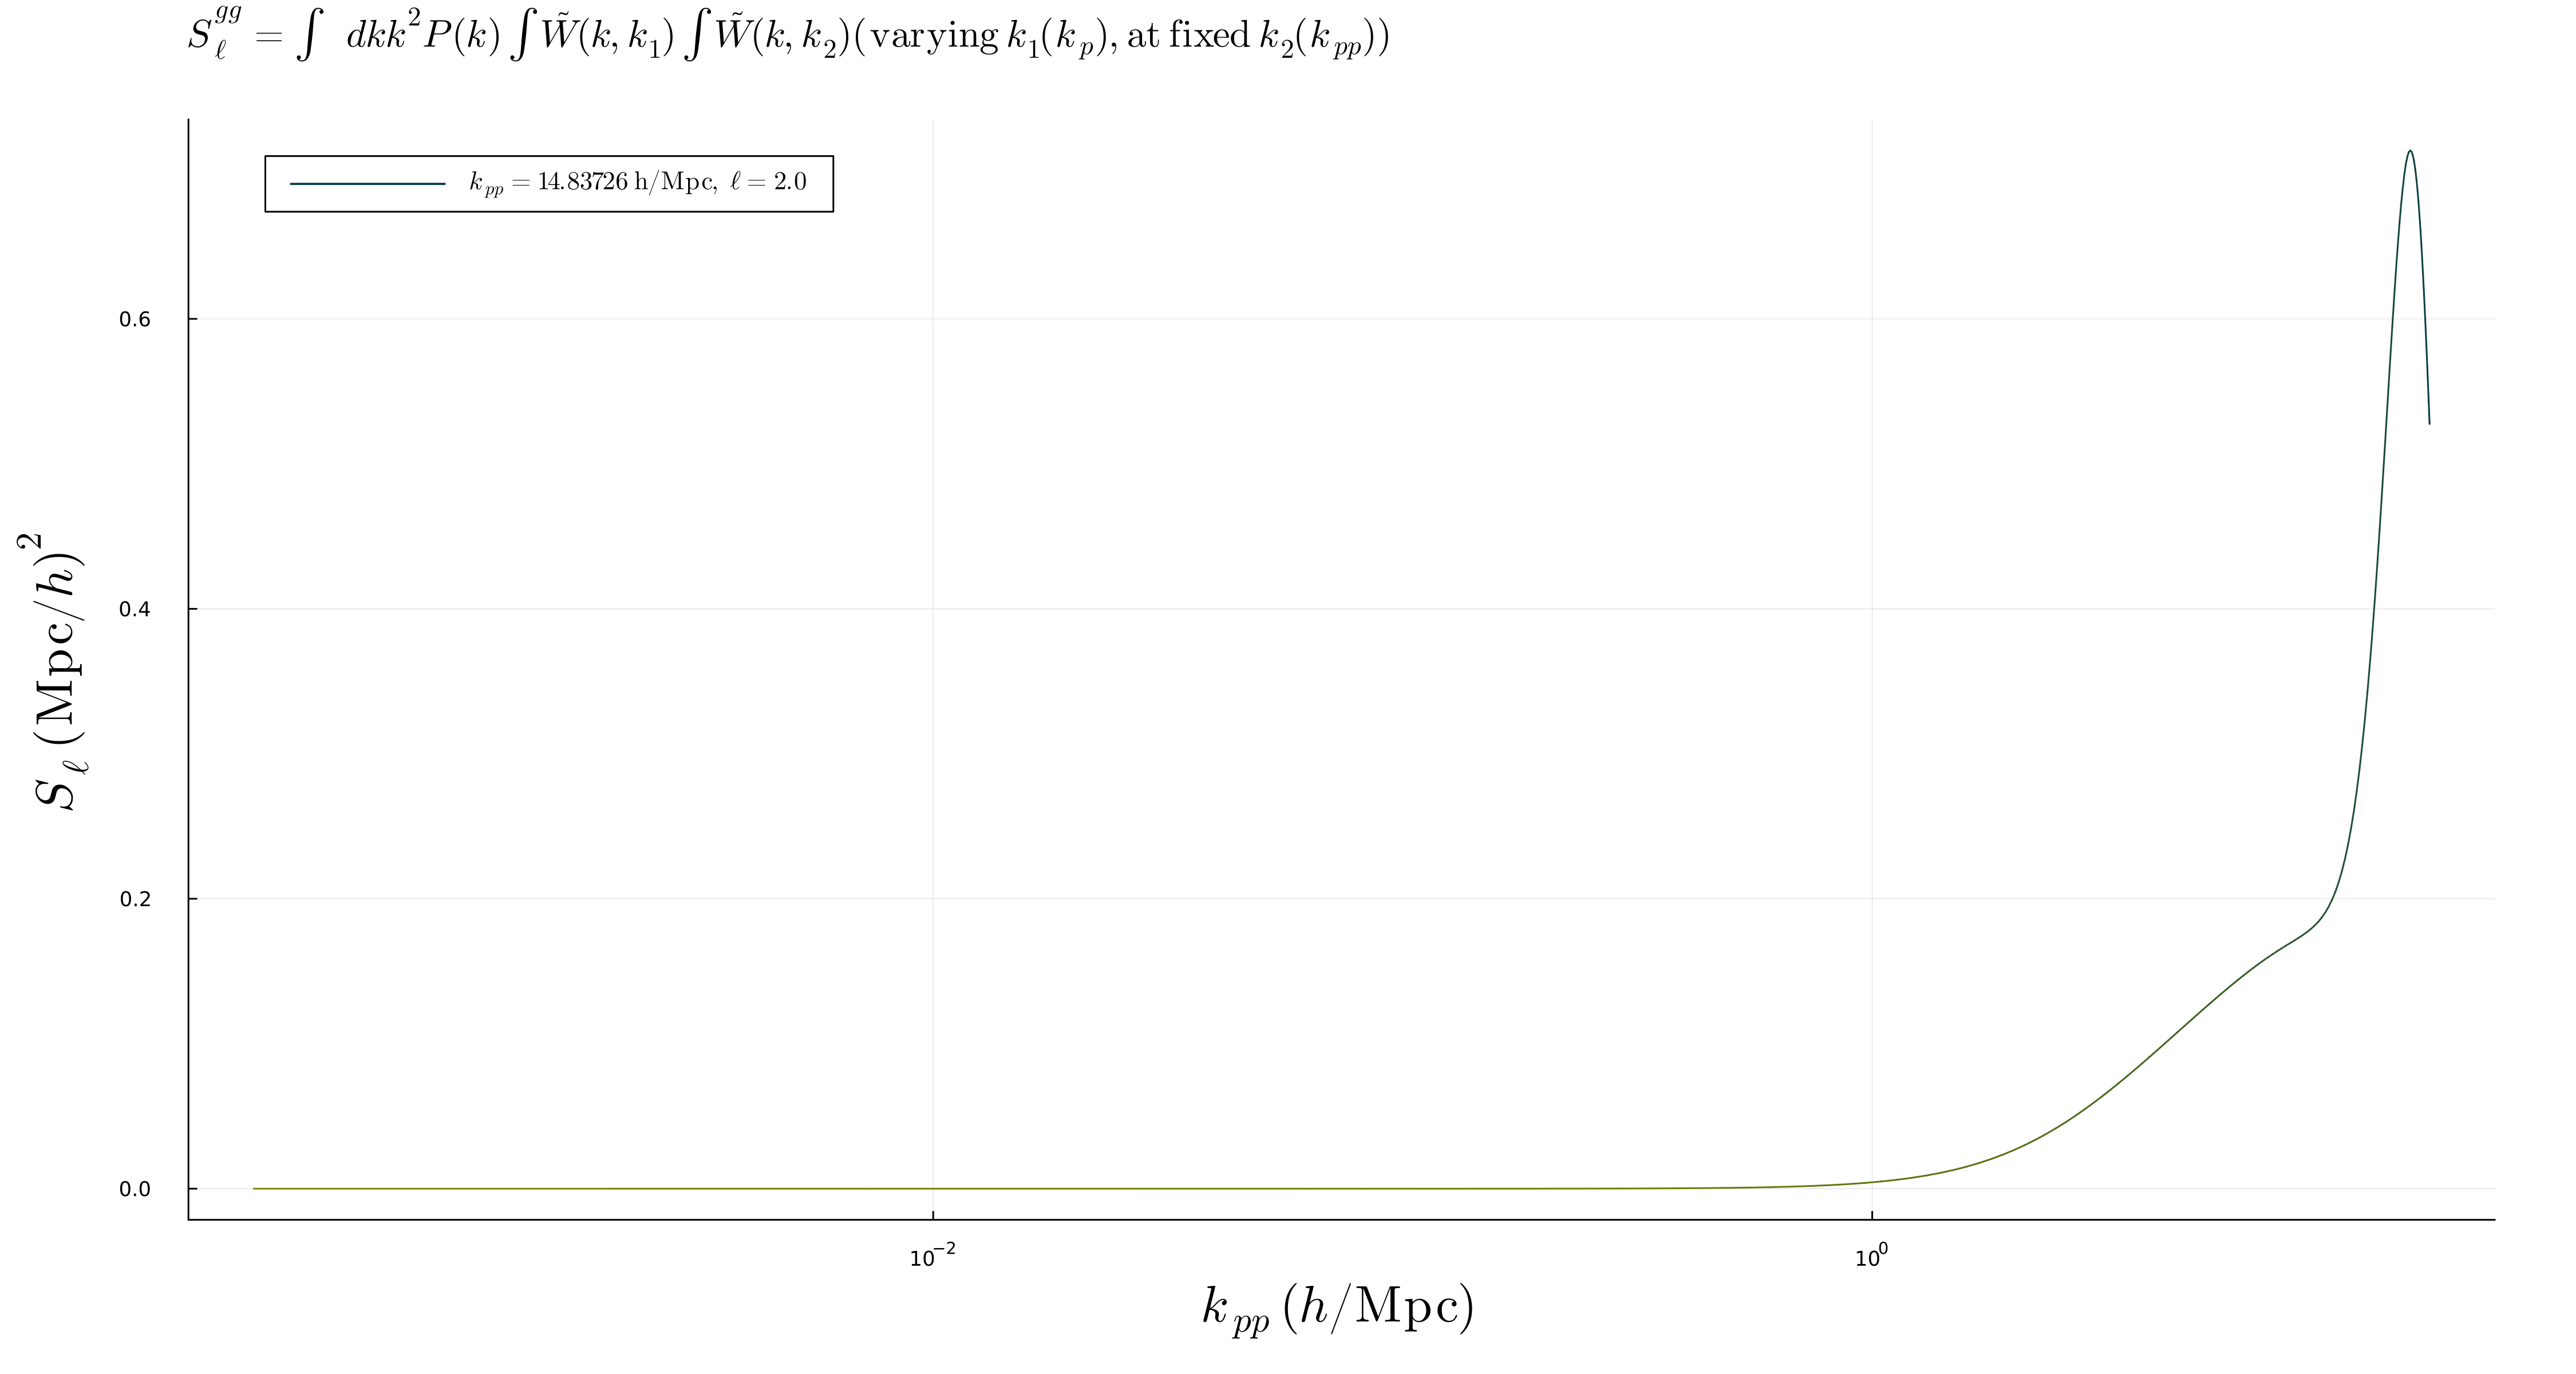

In [98]:
plt = plot()
il = 1
println("ℓ = ", grid_data.ℓ[il])
println("ℓ is fixed always")
ikpp = 19
println("k_1 (k_p) varies at each iteration")
println("k_2 (k_pp) = ", grids.kp_grid[ikpp] , " h/Mpc - fixed, stays there")
k_pp = grids.kp_grid[ikpp]
plot(grids.k_grid, S_lkk_gg[:, ikpp, il], 
color = plot_theme.colors[:],
label = L"k_{pp} = %$(round(k_pp, digits=5)) \; \mathrm{h/Mpc}, \; ℓ = %$(grid_data.ℓ[il])",
linestyle = :solid)
plot!(xaxis = L"k_{pp} \; (h/\mathrm{Mpc})",
      ylabel = L"S_\ell \; (\mathrm{Mpc}/h)^2"
      ,xscale = :log10
     )
plot!( title = L"S_\ell^{gg} = \int dk k^2 P(k) \int \tilde W(k, k_1) \int \tilde W(k, k_2) (\mathrm{varying} \; k_1 (k_p), \mathrm{at} \; \mathrm{fixed} \; k_2 (k_{pp}))",
      titlefontsize = 20,
      label = L"\ell=%$(grid_data.ℓ[il]), k_pp=%$(round(k_pp, digits=3)) \; \mathrm{h/Mpc}",
      titleposition = :left, labelfontsize = 20, labelposition = :topright,
      legendposition = :topleft, 
      size=plot_theme.size_Cl; plot_theme.shared_style...)

ℓ = 2.0
ℓ is fixed always
k_1 (k_p) varies at each iteration
k_2 (k_pp) is fixed at each iteration


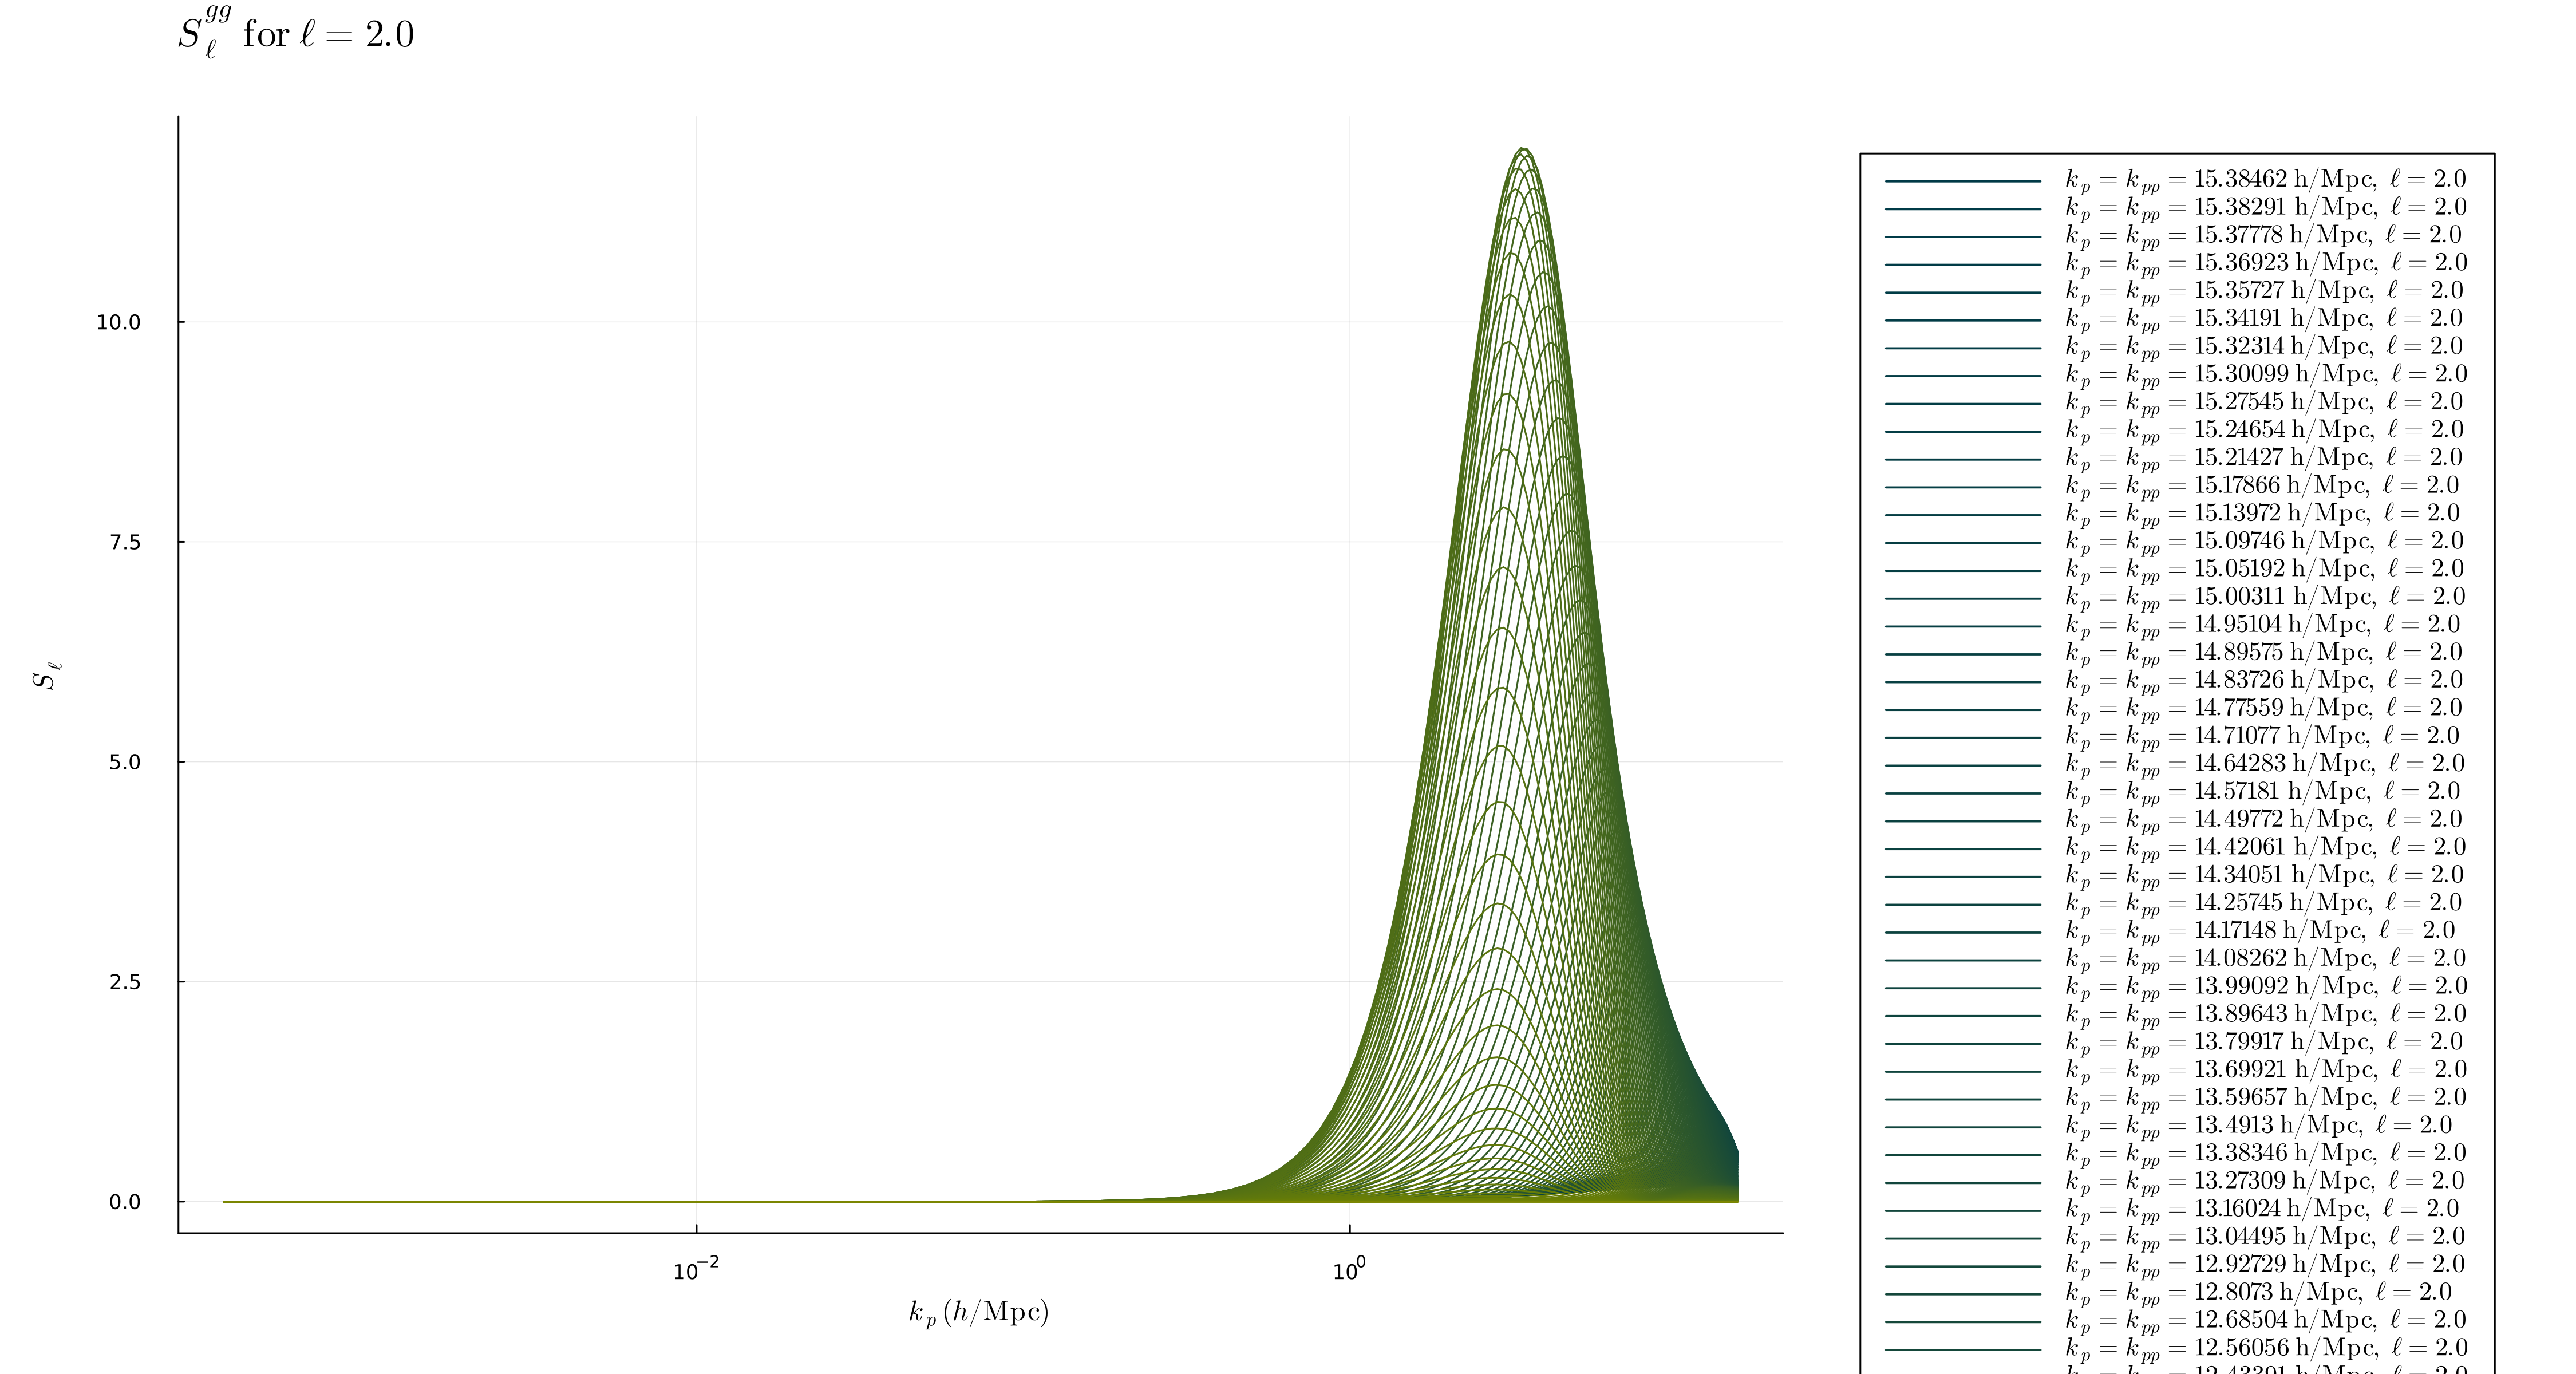

In [92]:
plt = plot()
il = 1
for ip in 1:grid_data.Nkp
    kp = grids.k_grid[ip]
    kpp = grids.kp_grid[ip]
end
println("ℓ = ", grid_data.ℓ[il])
println("ℓ is fixed always")
println("k_1 (k_p) varies at each iteration")
println("k_2 (k_pp) is fixed at each iteration")
for ip in 1:grid_data.Nkp
    kp = grids.k_grid[ip]
    kpp = grids.kp_grid[ip]
    plot!(grids.k_grid, S_lkk_gg[:,ip,il], 
    color = plot_theme.colors[ip], 
    label = L"k_p = k_{pp} = %$(round(kp, digits=5)) \; \mathrm{h/Mpc}, \; ℓ = %$(grid_data.ℓ[il])",
    linestyle = :solid)
end
plot!(xaxis = L"k_{p} \; (h/\mathrm{Mpc})",
      ylabel = L"S_\ell"
      ,xscale = :log10, label = ""
     )
plot!(title = L"S_\ell^{gg} \; \mathrm{for} \; \ell = %$(grid_data.ℓ[il])",
      legendposition = :outertopright, size = plot_theme.size_Cl, titlefontsize = 20, titleposition = :left; plot_theme.shared_style...)

ℓ changes at each iteration
k_1 (k_p) varies at each iteration
k_2 (k_pp) is kept fixed for every iteration


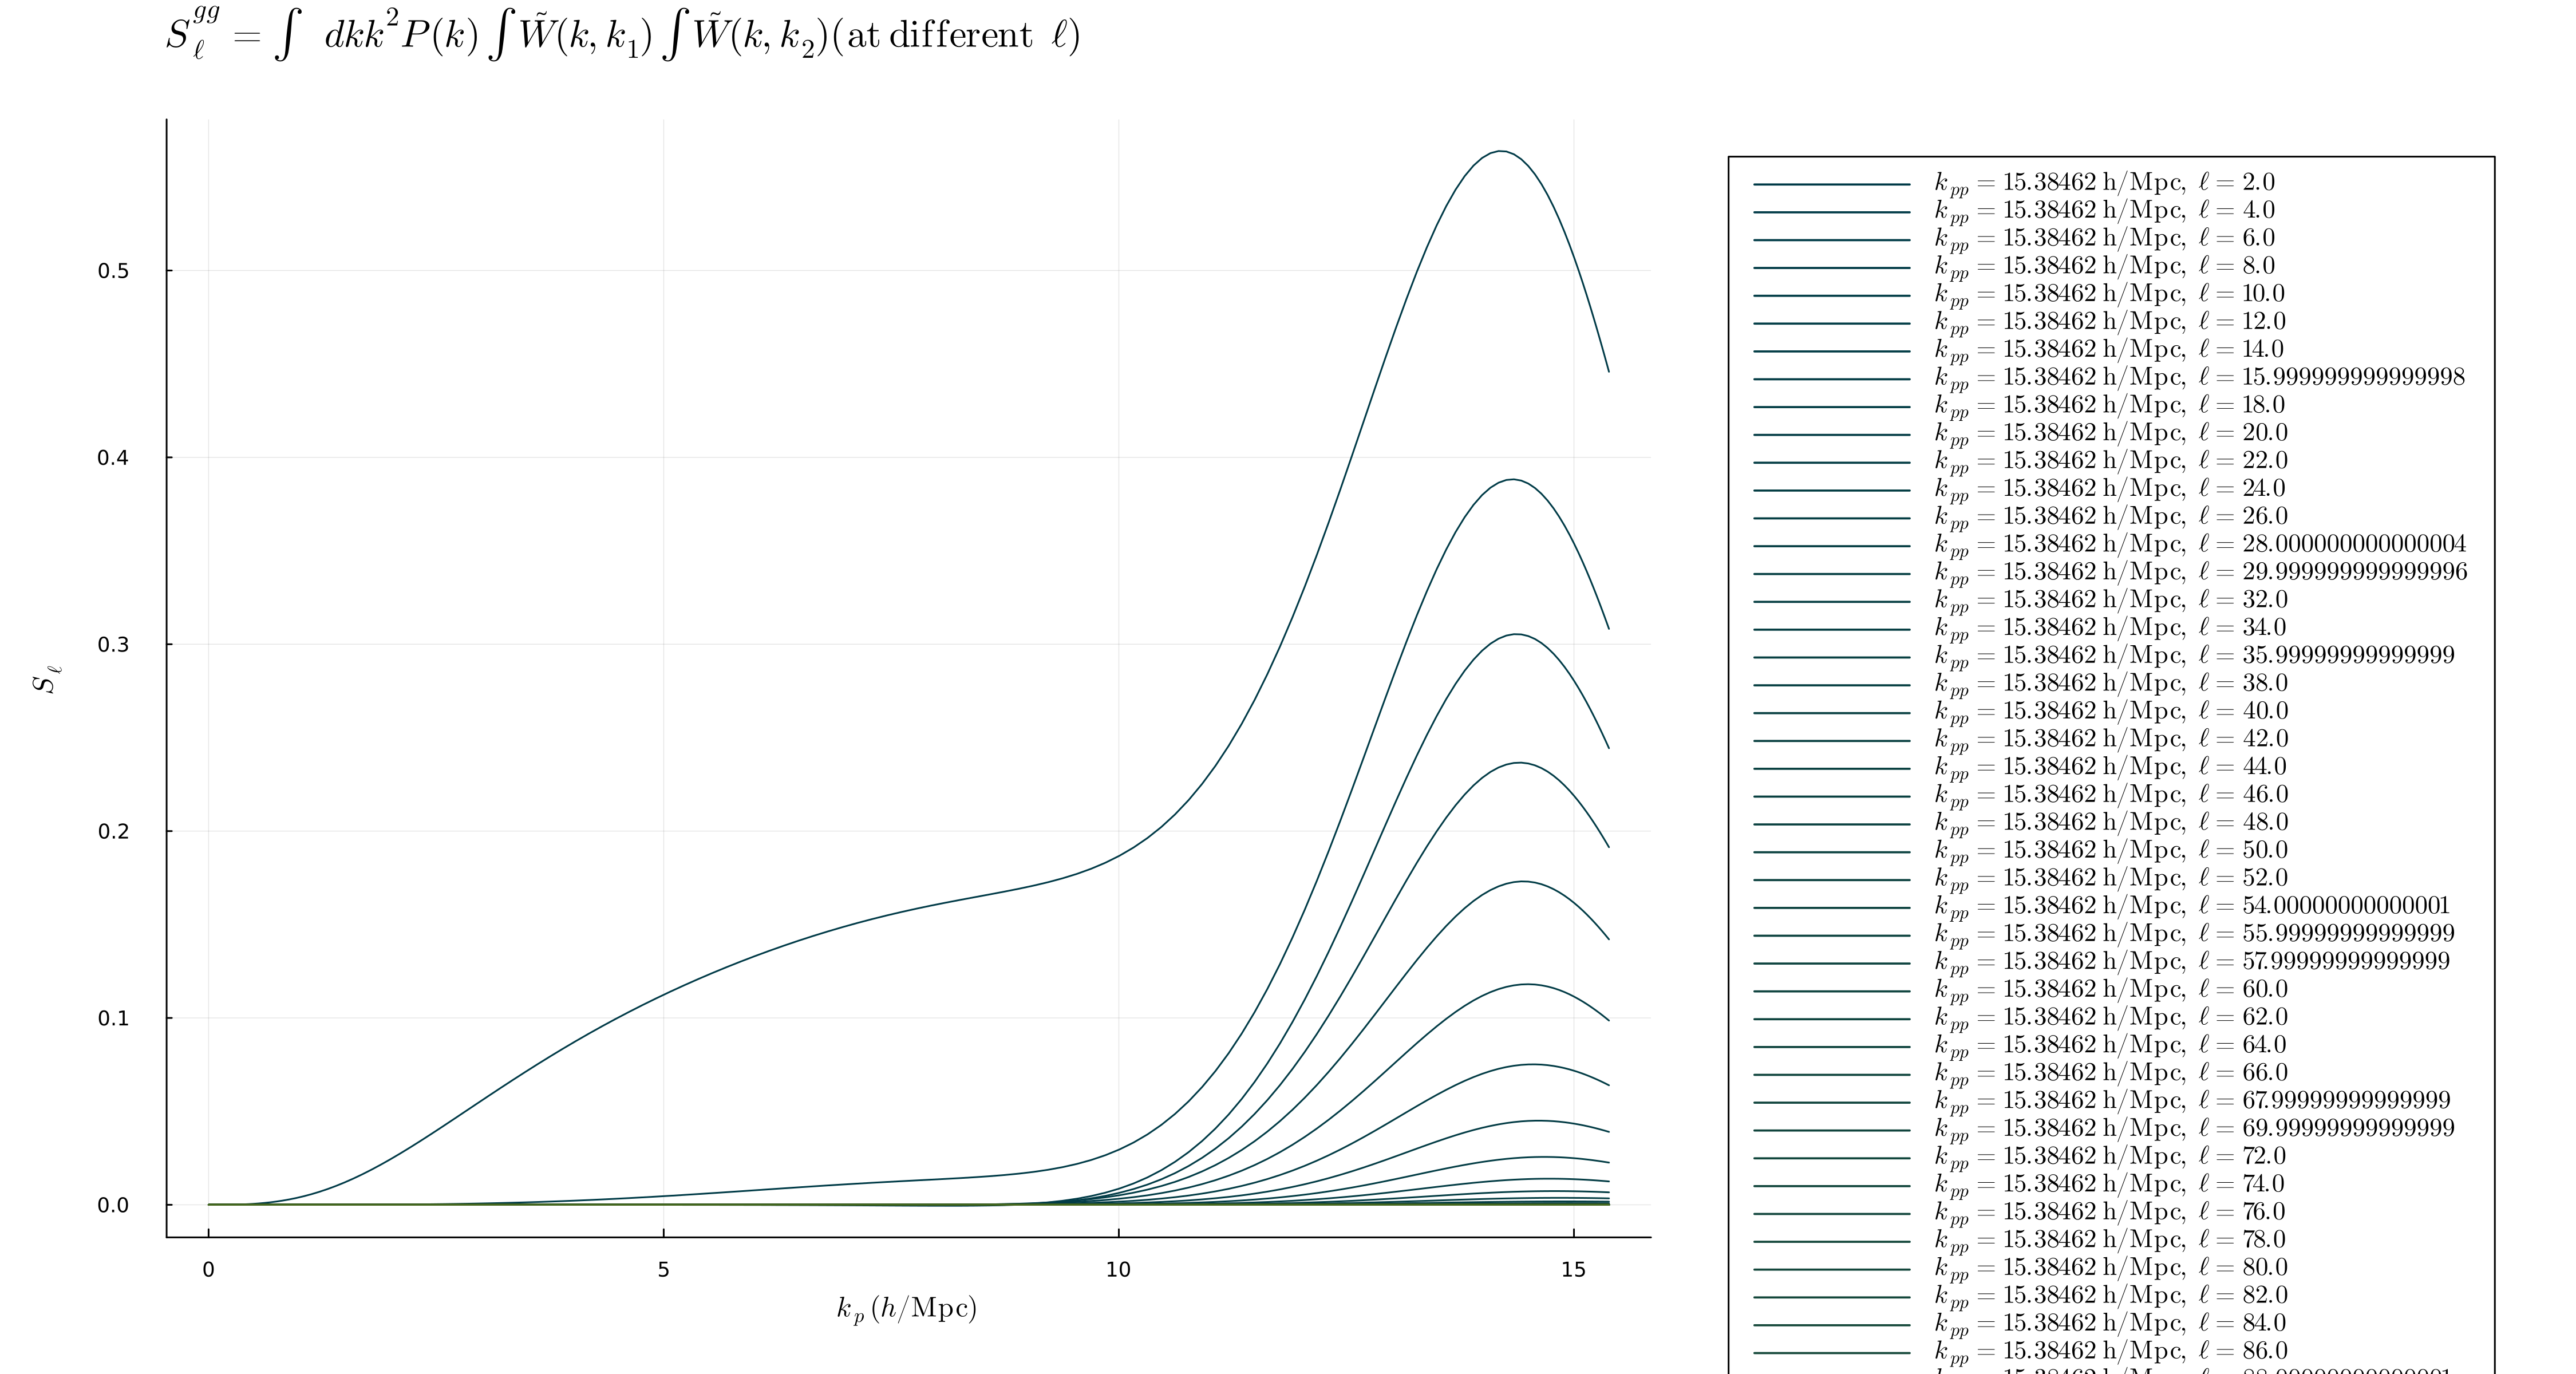

In [93]:
plt = plot()
ipp = 1
kpp = grids.kp_grid[ipp]
println("ℓ changes at each iteration")
println("k_1 (k_p) varies at each iteration")
println("k_2 (k_pp) is kept fixed for every iteration")
for il in 1:length(grid_data.ℓ)
    plot!(grids.k_grid, S_lkk_gg[:,ipp,il], 
    color = plot_theme.colors[il], 
    label = L"k_{pp} = %$(round(kpp, digits=5)) \; \mathrm{h/Mpc}, \; ℓ = %$(grid_data.ℓ[il])",
    linestyle = :solid)
end
plot!(xaxis = L"k_{p} \; (h/\mathrm{Mpc})",
      ylabel = L"S_\ell"
      #,xscale = :log10
     )
plot!( title = L"S_\ell^{gg} = \int dk k^2 P(k) \int \tilde W(k, k_1) \int \tilde W(k, k_2) (\mathrm{at} \; \mathrm{different} \; \; \ell )",
      titlefontsize = 20,
      label = L"\ell=%$(grid_data.ℓ[il]), \; \mathrm{h/Mpc}",
      titleposition = :left, legend = nothing,
      legendposition = :outertopright, 
      size=plot_theme.size_Cl; plot_theme.shared_style...)

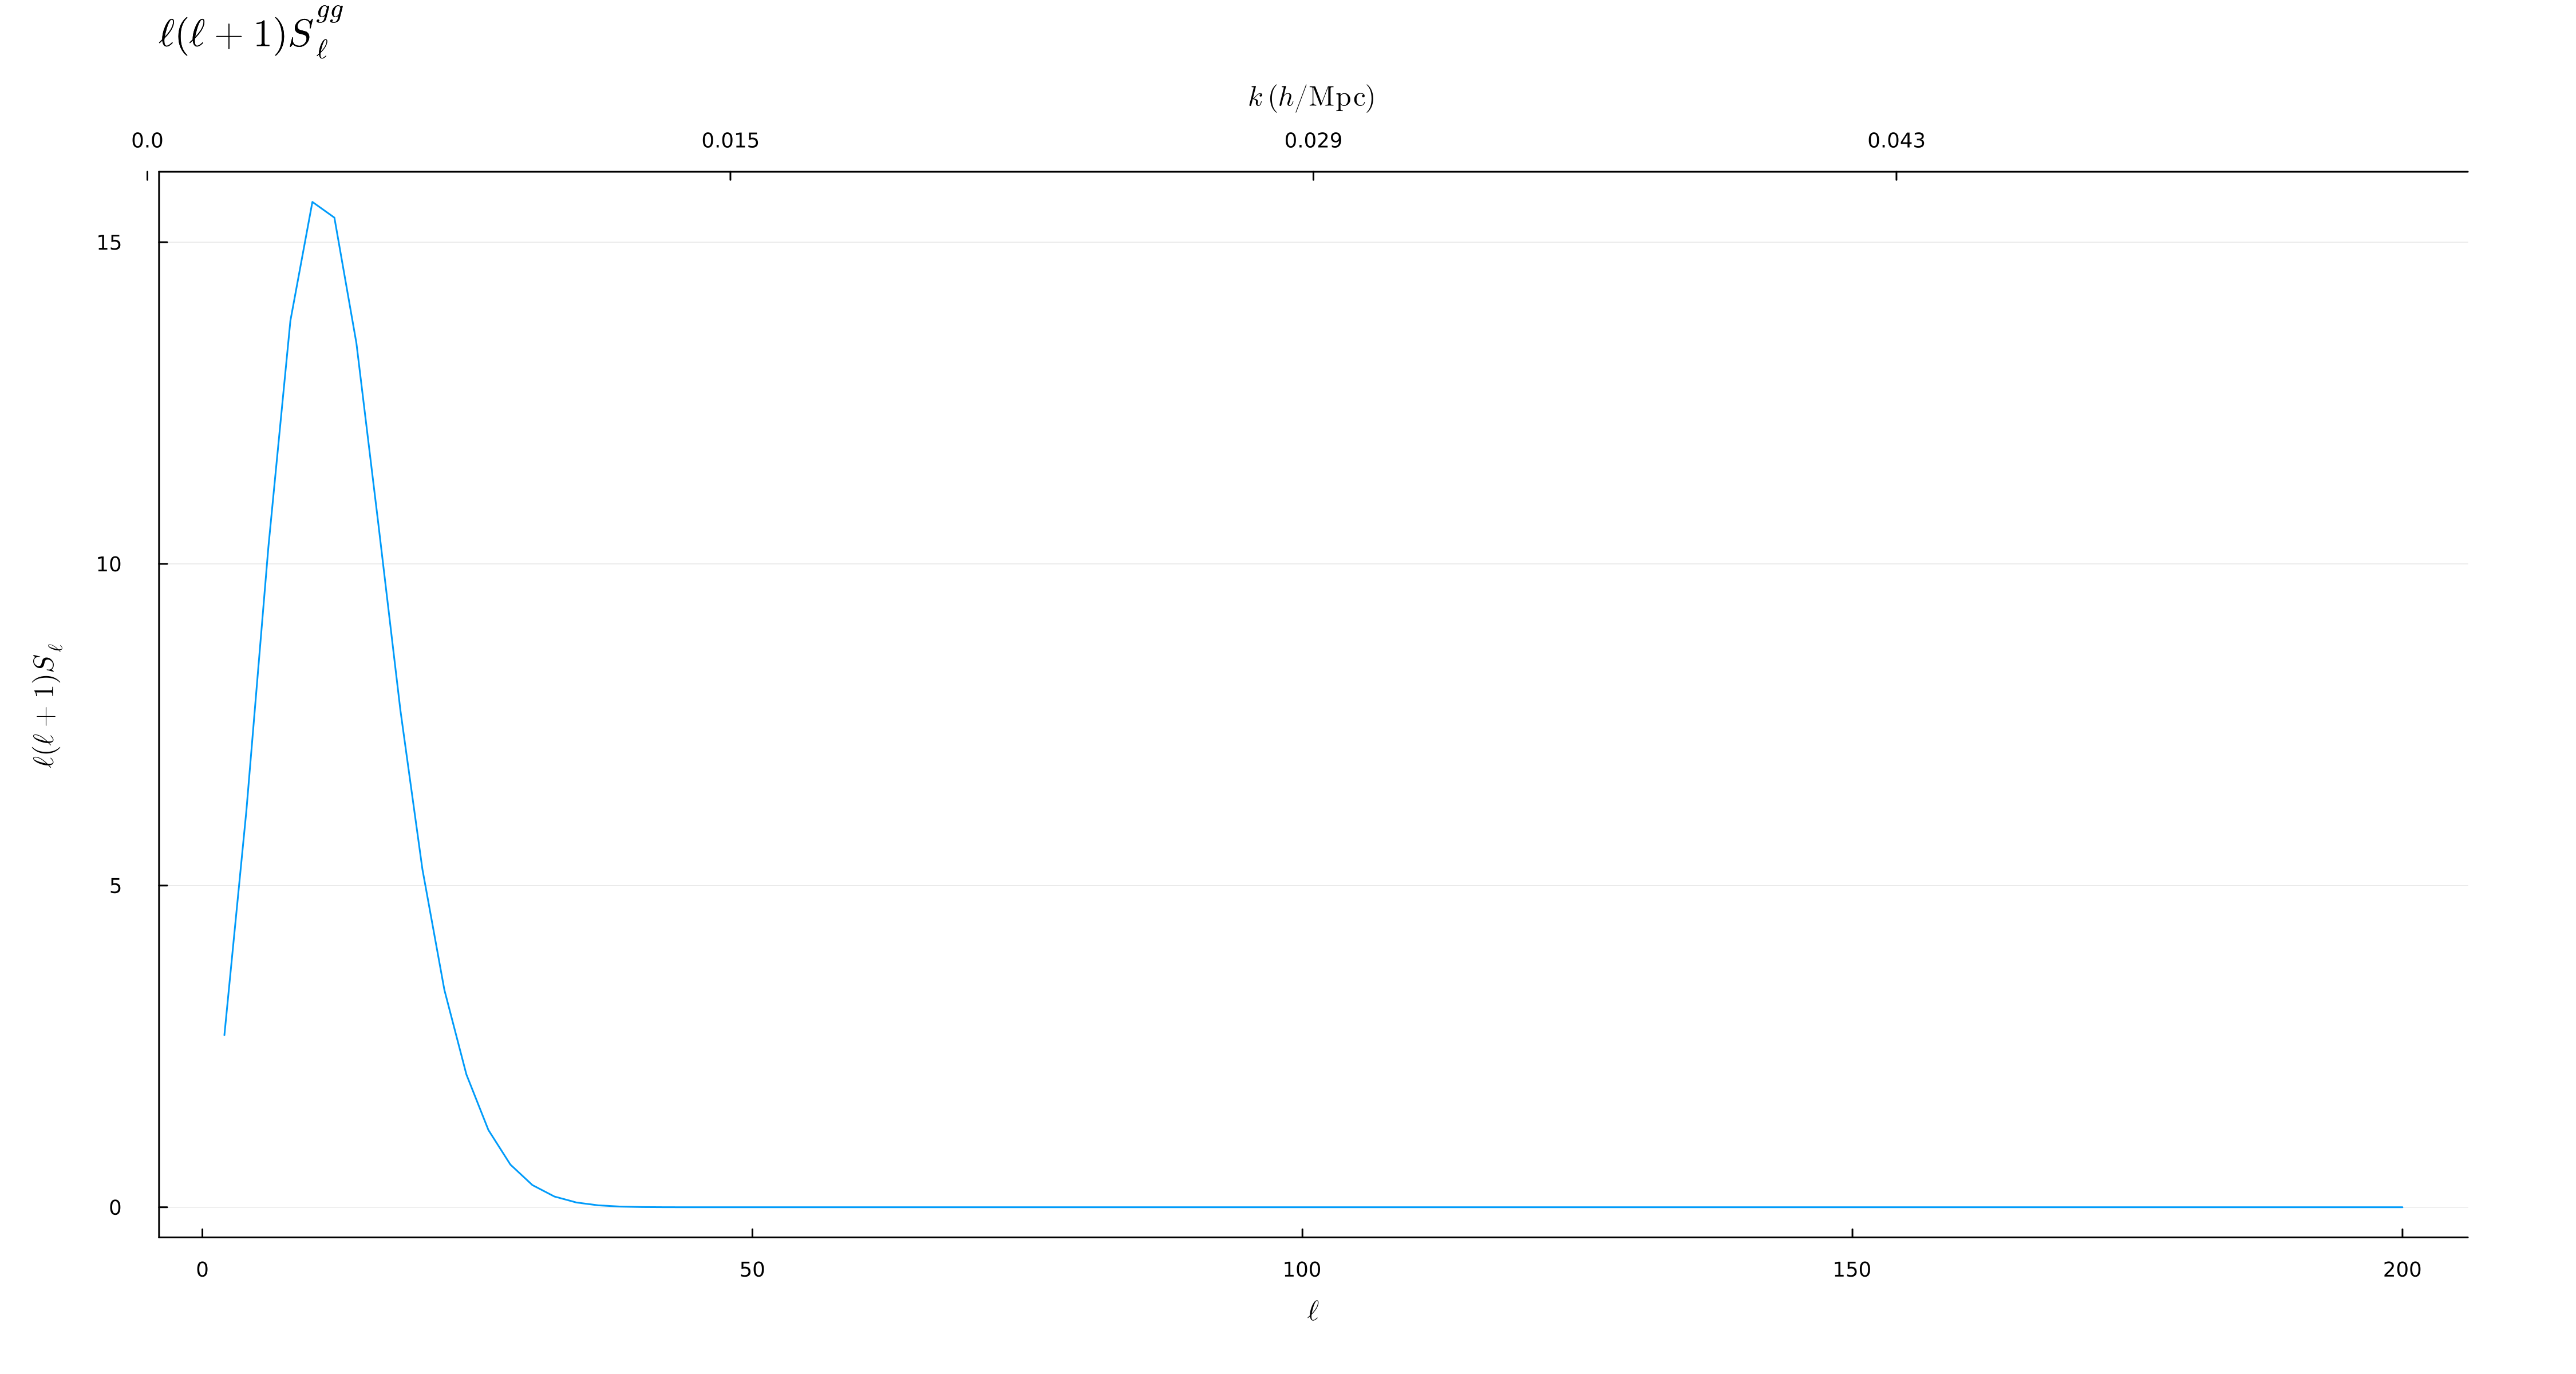

In [94]:
plt = plot()
ip = 1
ipp = 1
plot(
    grid_data.ℓ,
    S_lkk_gg[ip, ipp, :] .* grid_data.ℓ .* (grid_data.ℓ .+ 1),
    xaxis = L"\ell",
    yaxis = L"\ell(\ell+1)S_\ell",
)

plot!(twiny(),
      xaxis = L"k \; (h/\mathrm{Mpc})",
      xticks = (ℓ_ticks, k_ticklabels),
      xlims = (minimum(grid_data.ℓ), maximum(grid_data.ℓ)),
      label = ""
     )

plot!(label = "Beyond BLAST", 
    legend = false, colorbar = true, colorbar_title = L"j", clims = (1, grid_data.Nkp),
    title = L"\ell(\ell+1)S_\ell^{gg}",
    size=plot_theme.size_Cl, titlefontsize=20, 
    titleposition = :left;
    plot_theme.shared_style...
    )

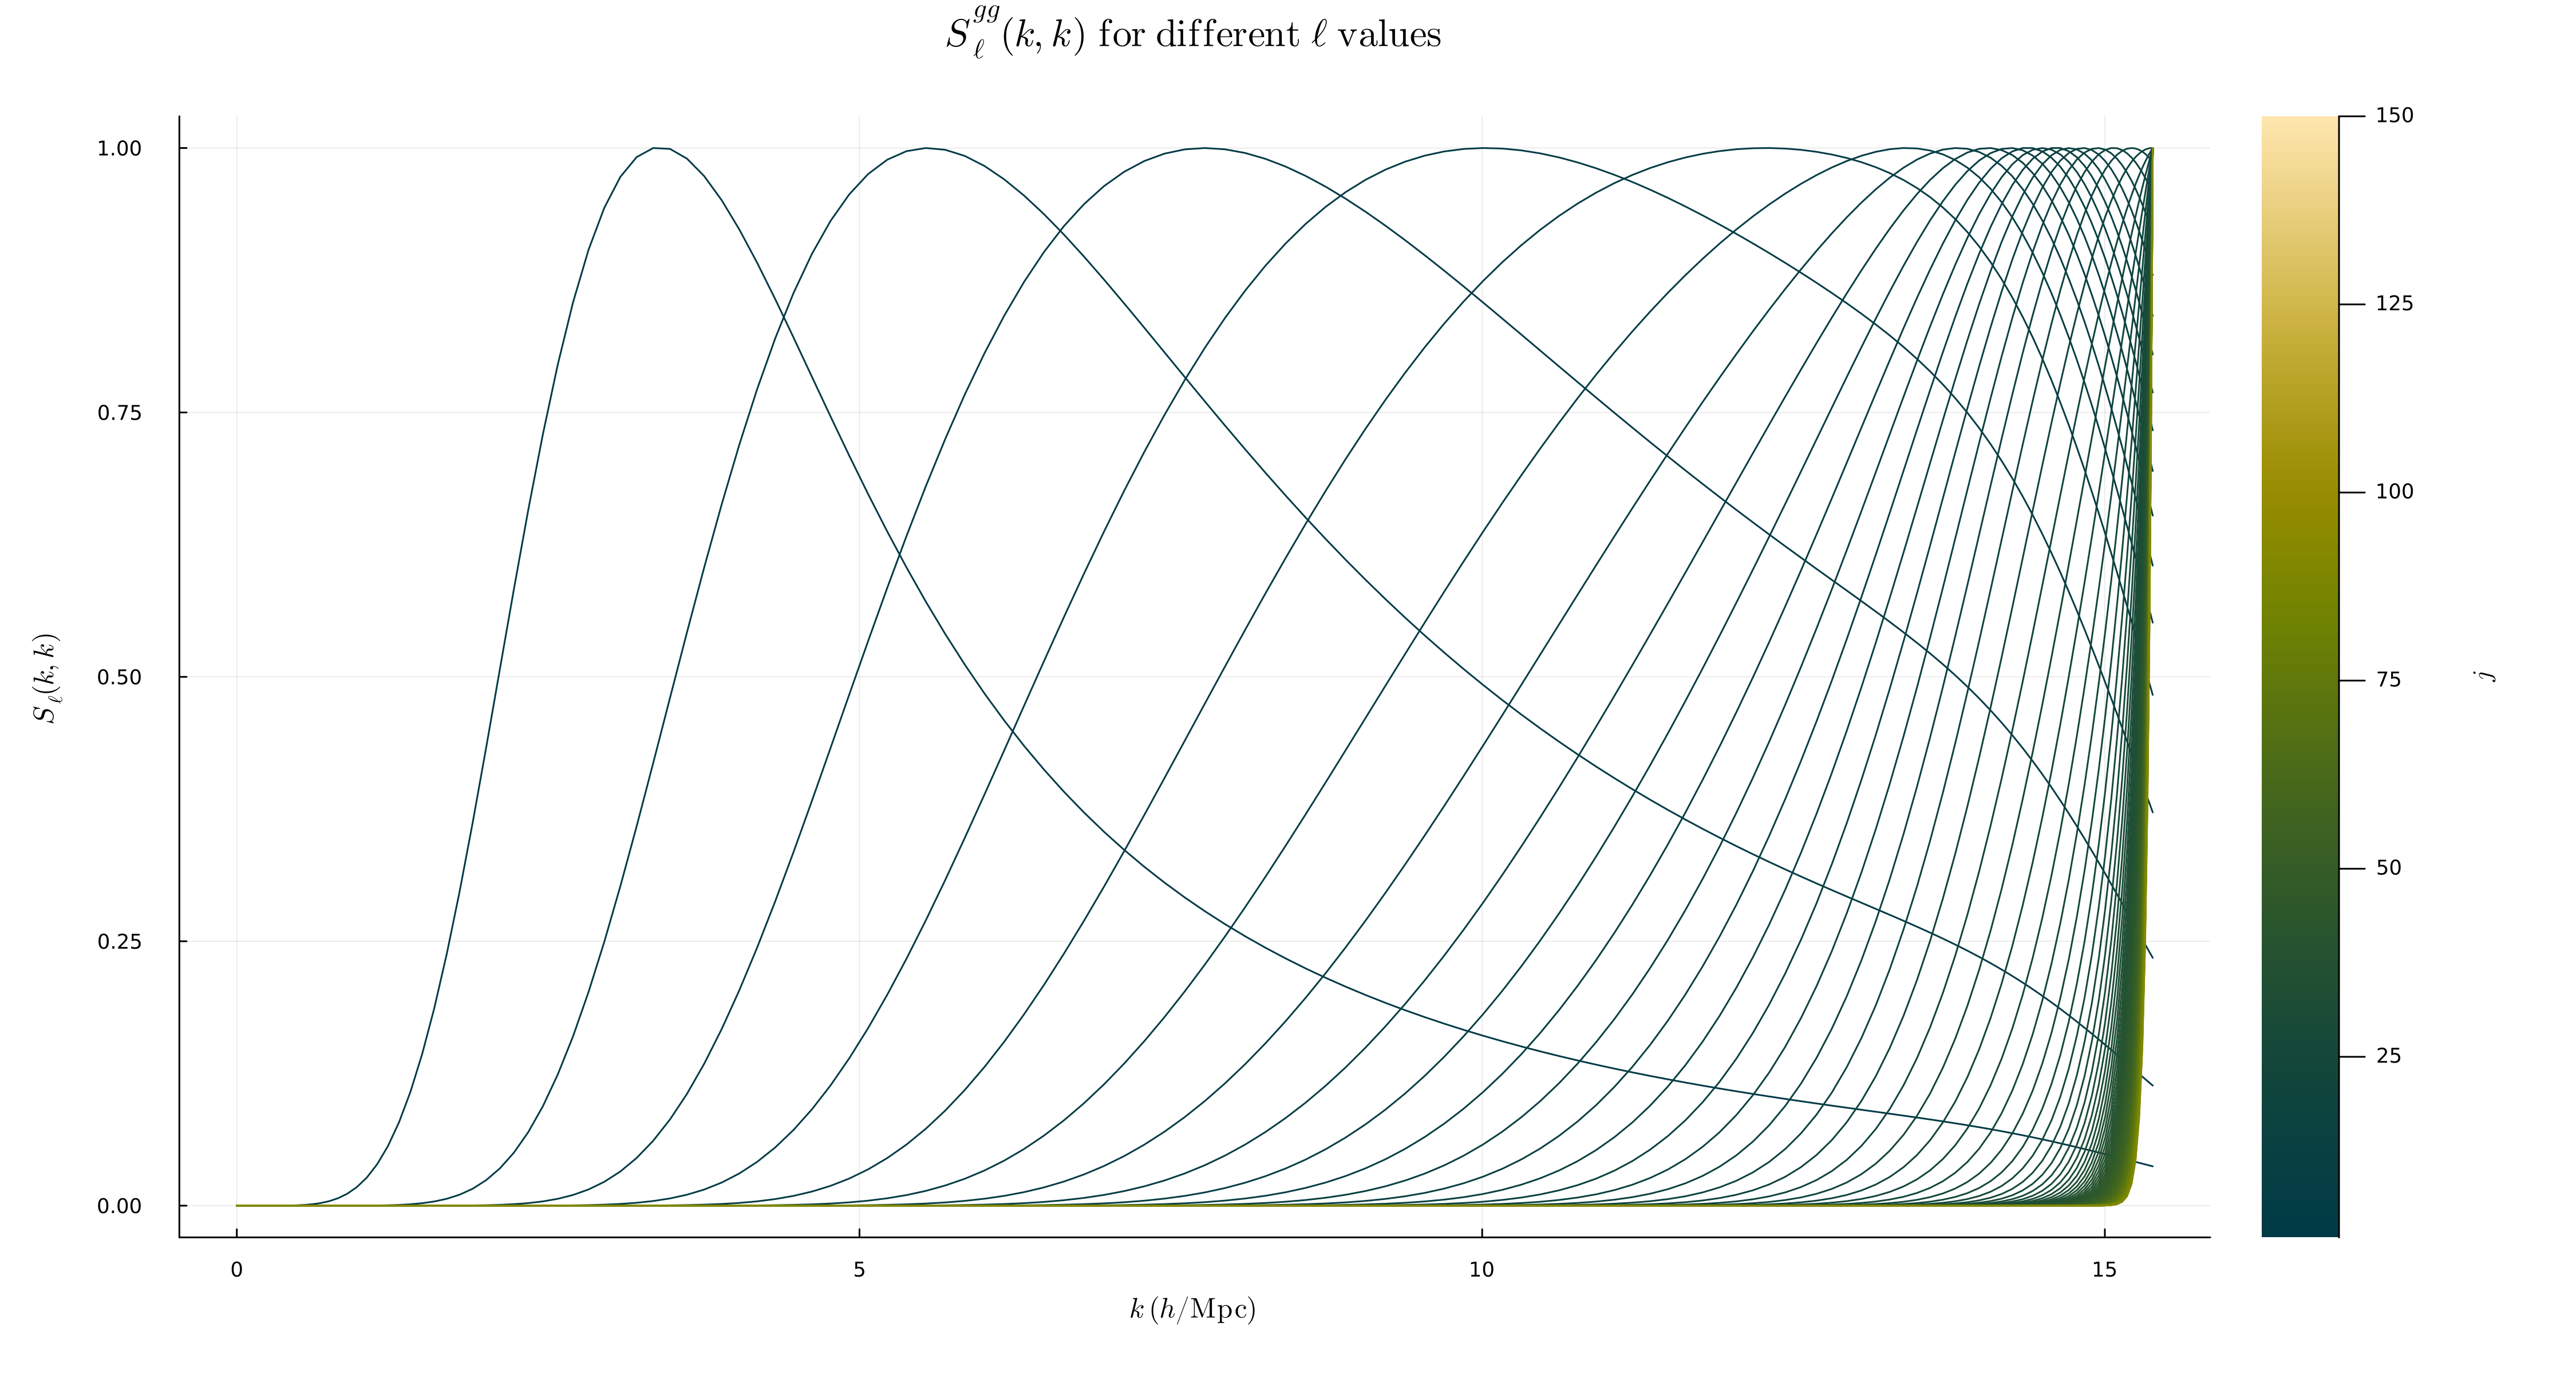

In [95]:
diagS = [diag(S_lkk_gg[:, :, i]) for i in 1:size(S_lkk_gg, 3)]

nshow = 100
idx = round.(Int, range(1, size(S_lkk_gg, 3), length=nshow))

p = plot(
    xlabel = L"k \; (h/\mathrm{Mpc})",
    ylabel = L"S_\ell(k,k)",
    title  = L"S_\ell^{gg}(k,k)\ \mathrm{for\ different}\ \ell\ \mathrm{values}",
    colorbar_title = L"j",
    clims = (1, grid_data.Nkp),                   
    legend = false,
    colorbar = true,
    lw = 2,
    size=plot_theme.size_Cl; plot_theme.shared_style...
)

for ii in idx
    plot!(p, grids.kp_grid, diagS[ii]/maximum(diagS[ii]), line_z = ii, color = plot_theme.colors;
        label = L"\ell = %$(grid_data.ℓ[ii])")
end

p

In [100]:
println(grids.k_grid[147])
println(grids.k_grid[147])
println(grid_data.ℓ[2])

println(S_lkk_gg[3,3,2])
println(S_lkk_gg[147,147,2])

0.01574015850603505
0.01574015850603505
4.0
0.31009775713691917
2.4976298910989194e-22


---